In [1]:
# ruff: noqa: F405

from _shared import pl_k_sP, psc_ds, run_deg_groups, run_nmf, run_proc_per_ds, viz_defs, comp_spat_stats  # isort:skip

from functools import partial
from pathlib import Path
from pickle import dump, load
from warnings import catch_warnings, simplefilter

import anndata as ad
import numpy as np
import scanpy as sc
import uapl
import upsetplot as up
from matplotlib import pyplot as plt
from plotnine import *  # noqa: F403

import spatialpeeler as sP
from spatialpeeler.diag import comp_sparsity, sweep_uns

In [2]:
viz_defs(dpi=128)
RAND_SEED = 28
# define helper function for plotting
pl_help = partial(pl_k_sP, cond_col="group", sample_col="sample_id", ctl_val="CTL")
SP_FACT_PAT_STR = "sP_p_hat_k={k}"
SP_GENE_PAT_STR = "sp_gene_id_k={k}"

In [3]:
# load dataset + run NMF
if (pth := Path("../.cache/psc.pkl")).exists():
    with open(pth, "rb") as f:
        psc = load(f)
else:
    adatas = psc_ds(
        Path("../data/psc-visium"),
    )
    for k in adatas:
        adatas[k] = adatas[k][adatas[k].obs["in_tissue"], :]

    run_proc_per_ds(adatas)

    psc = ad.concat(adatas, label="sample_id", index_unique="_")

    sc.pp.filter_genes(psc, min_cells=psc.n_obs // 500)

    psc.var["SYMBOL"] = (
        sc.queries.biomart_annotations("hsapiens", ["ensembl_gene_id", "external_gene_name"], host="grch37.ensembl.org")
        .set_index("ensembl_gene_id")
        .merge(psc.var.index.to_series(), left_index=True, right_index=True, how="right")["external_gene_name"]
        .fillna(psc.var.index.to_series())
    )

    run_nmf(psc, 30, RAND_SEED)

    pth.parent.mkdir(exist_ok=True)
    with open(pth, "wb") as f:
        dump(psc, f)
print(psc)

AnnData object with n_obs × n_vars = 21553 × 16465
    obs: 'in_tissue', 'percent.mt', 'cell_type', 'group', 'sample_id'
    var: 'n_cells', 'SYMBOL'
    obsm: 'spatial', 'X_nmf'
    varm: 'X_nmf'
    layers: 'counts'


with our processed data, we proceed with the factor-wise regression step of spatialPeeler

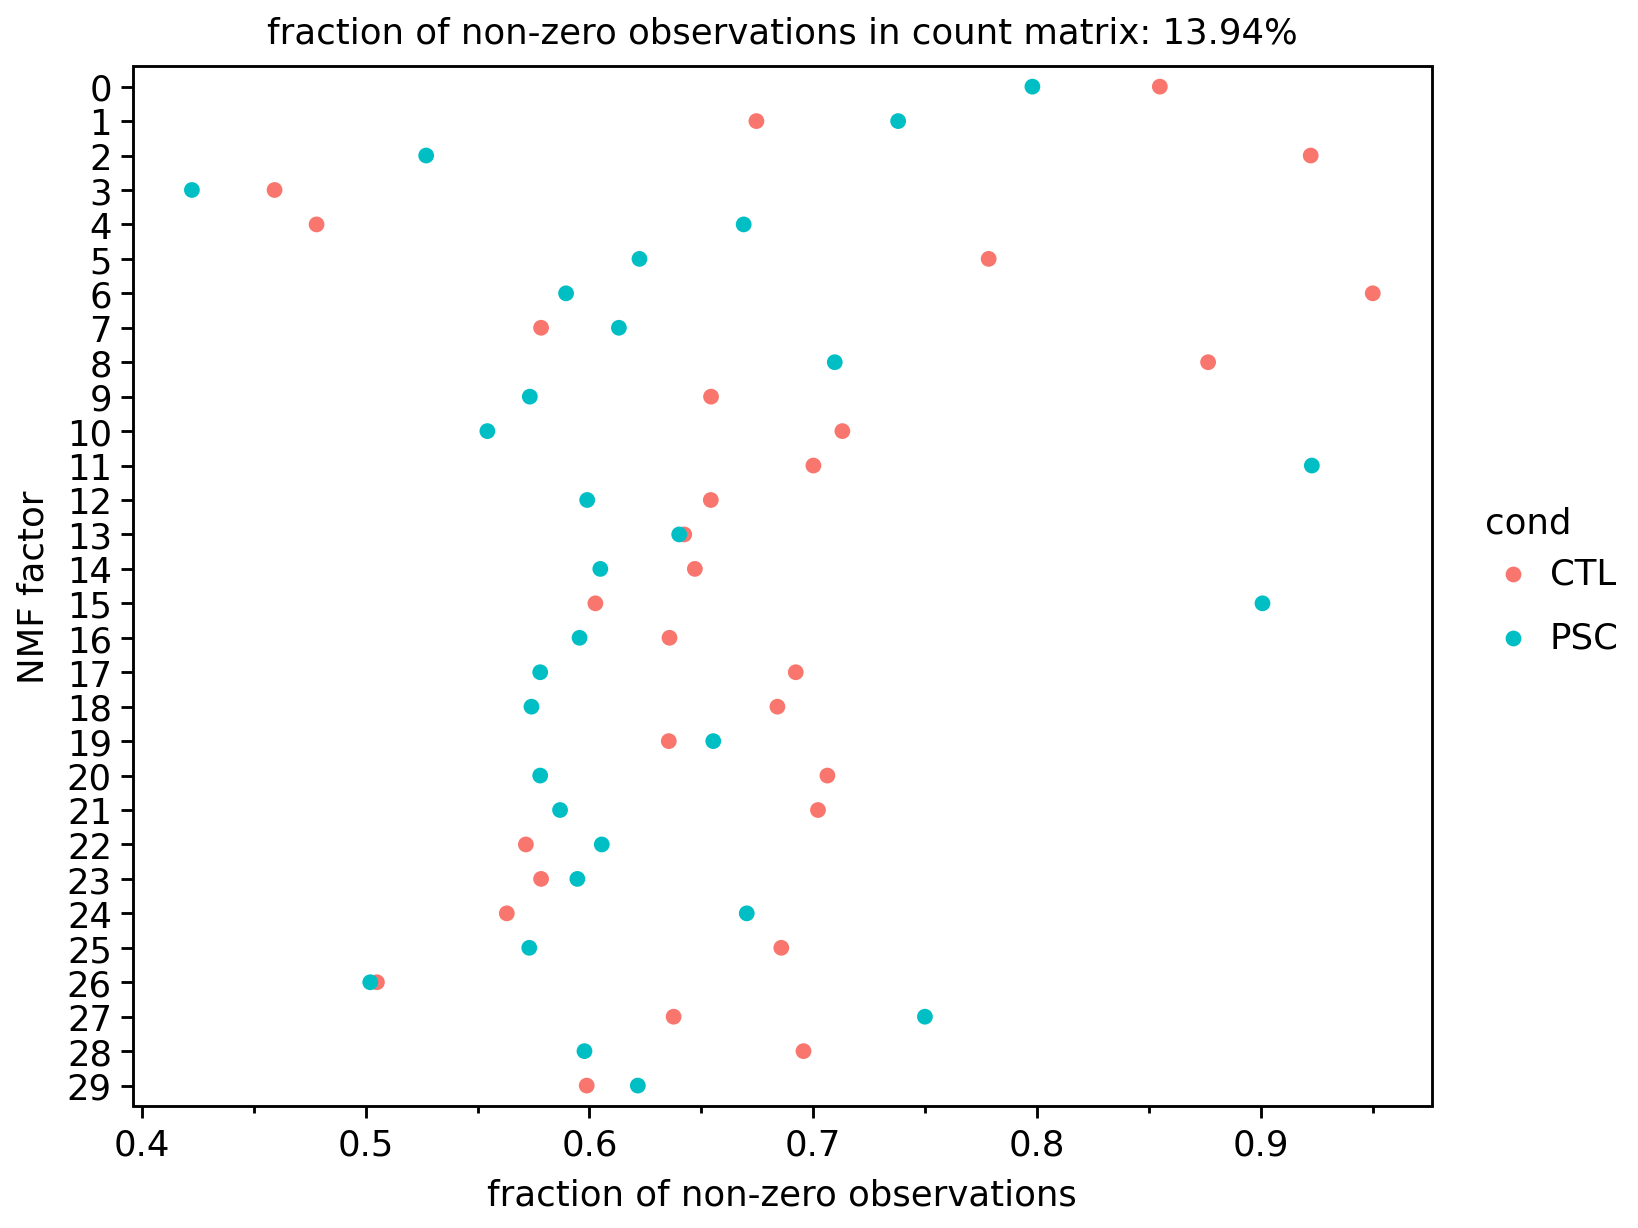

In [4]:
X_spars = psc.X.nnz / np.prod(psc.X.shape)  # ty:ignore[unresolved-attribute]
(
    comp_sparsity(psc.obsm["X_nmf"], cond=psc.obs["group"])
    >> ggplot()
    + aes(x="density", y="column", color="cond")
    + geom_point()
    + scale_y_discrete(limits=reversed)  # ty:ignore[invalid-argument-type]
    + labs(
        x="fraction of non-zero observations",
        y="NMF factor",
        title=f"fraction of non-zero observations in count matrix: {X_spars * 100:.02f}%",
    )
).show()

In [5]:
# run factor-wise regression step
for k in range(psc.obsm["X_nmf"].shape[1]):
    sP.run_fact_reg(psc, "group", "CTL", k, SP_FACT_PAT_STR.format(k=k), X_key="X_nmf")

print(psc)

AnnData object with n_obs × n_vars = 21553 × 16465
    obs: 'in_tissue', 'percent.mt', 'cell_type', 'group', 'sample_id'
    var: 'n_cells', 'SYMBOL'
    uns: 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_p_hat_k=16', 'sP_p_hat_k=17', 'sP_p_hat_k=18', 'sP_p_hat_k=19', 'sP_p_hat_k=20', 'sP_p_hat_k=21', 'sP_p_hat_k=22', 'sP_p_hat_k=23', 'sP_p_hat_k=24', 'sP_p_hat_k=25', 'sP_p_hat_k=26', 'sP_p_hat_k=27', 'sP_p_hat_k=28', 'sP_p_hat_k=29'
    obsm: 'spatial', 'X_nmf', 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_p_hat_k=16', 'sP_p_hat_k=17', 'sP_p_hat_k=18',

we now assess our resulting regression outputs distributions \
we can extract and collate the model betas and other statistics using the sweep_uns function

/workspaces/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log


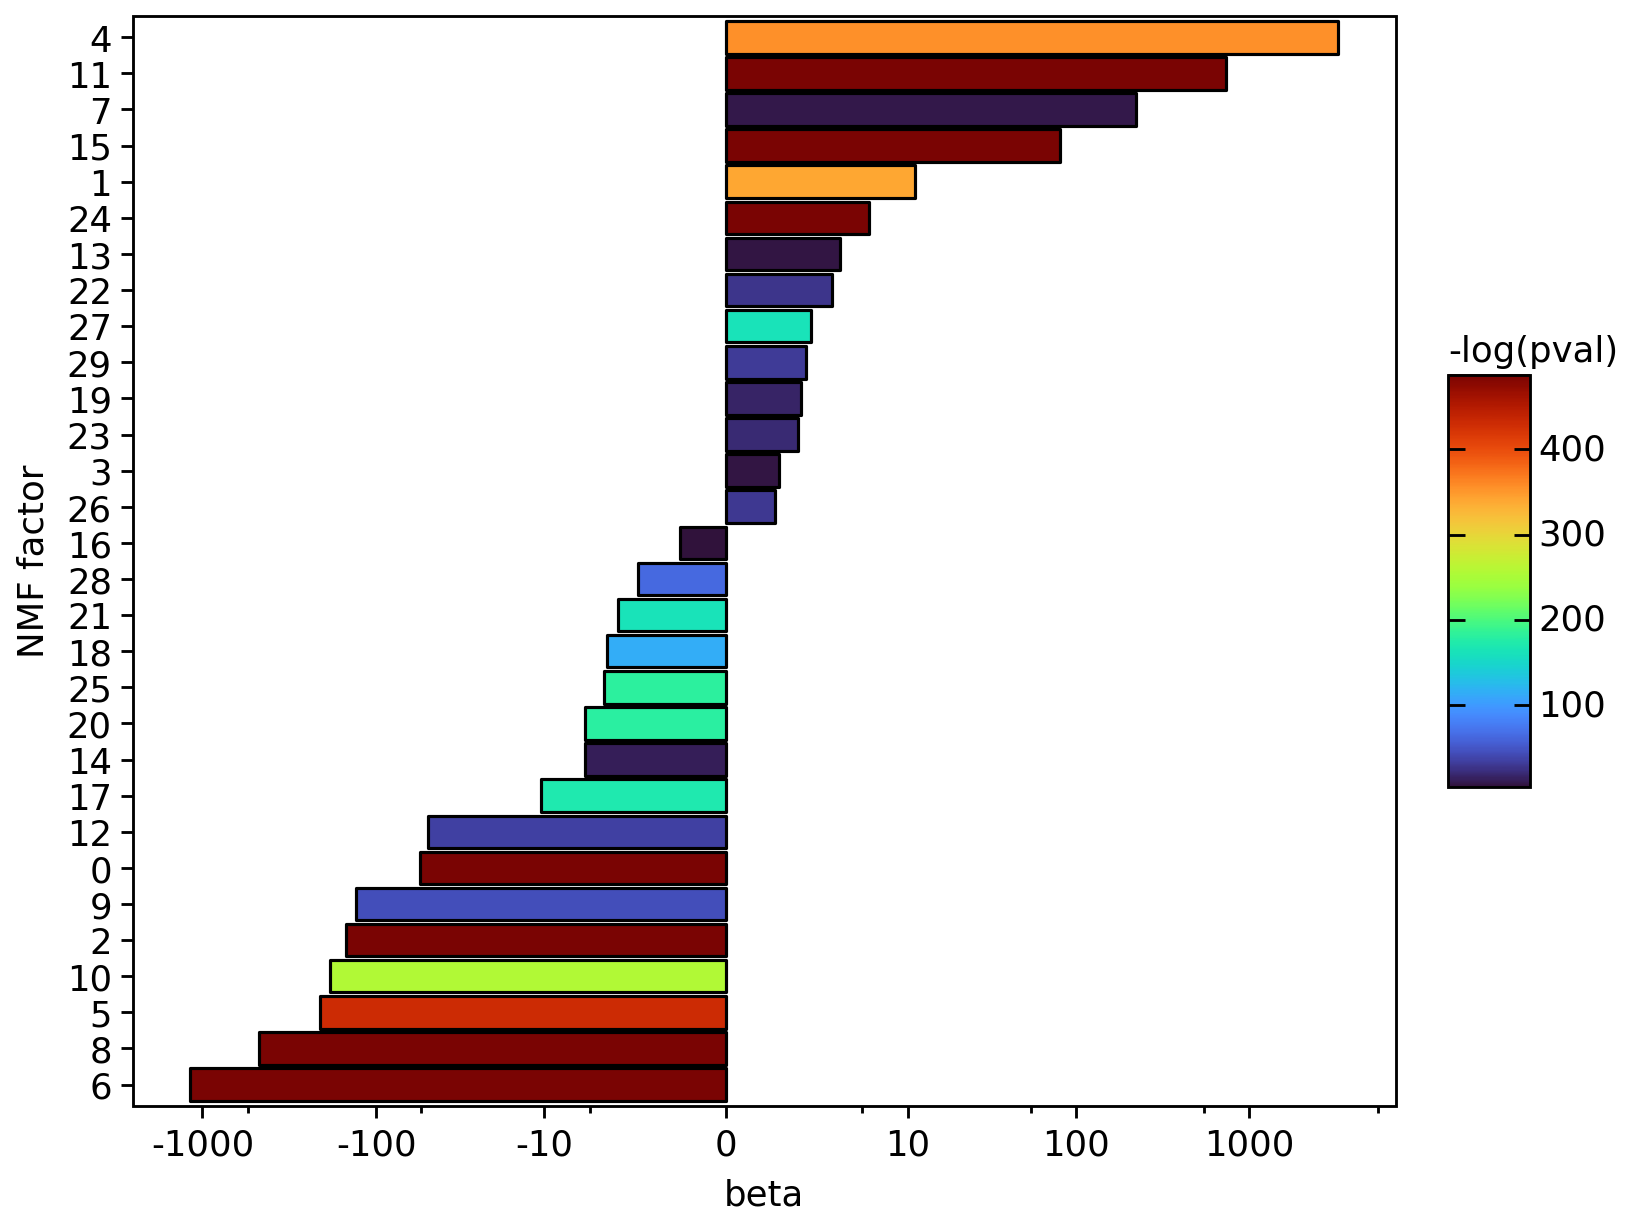

In [6]:
(
    sweep_uns(psc, SP_FACT_PAT_STR)
    >> ggplot()
    + aes(x="reorder(k, beta)", fill="-np.log(pval)", y="beta")
    + geom_col(color="black")
    + coord_flip()
    + labs(fill="-log(pval)", x="NMF factor")
    + scale_fill_cmap("turbo")
    + scale_y_symlog()
).show()

to explore the spatial properties of the resulting factor patterns, we can compute and plot
spatial statistics for each on a per sample basis (in this case Geary's C and Morans' I):

In [7]:
sp_stat_df, sp_stat_pl = comp_spat_stats(psc, SP_FACT_PAT_STR, "sample_id", "group", "CTL")

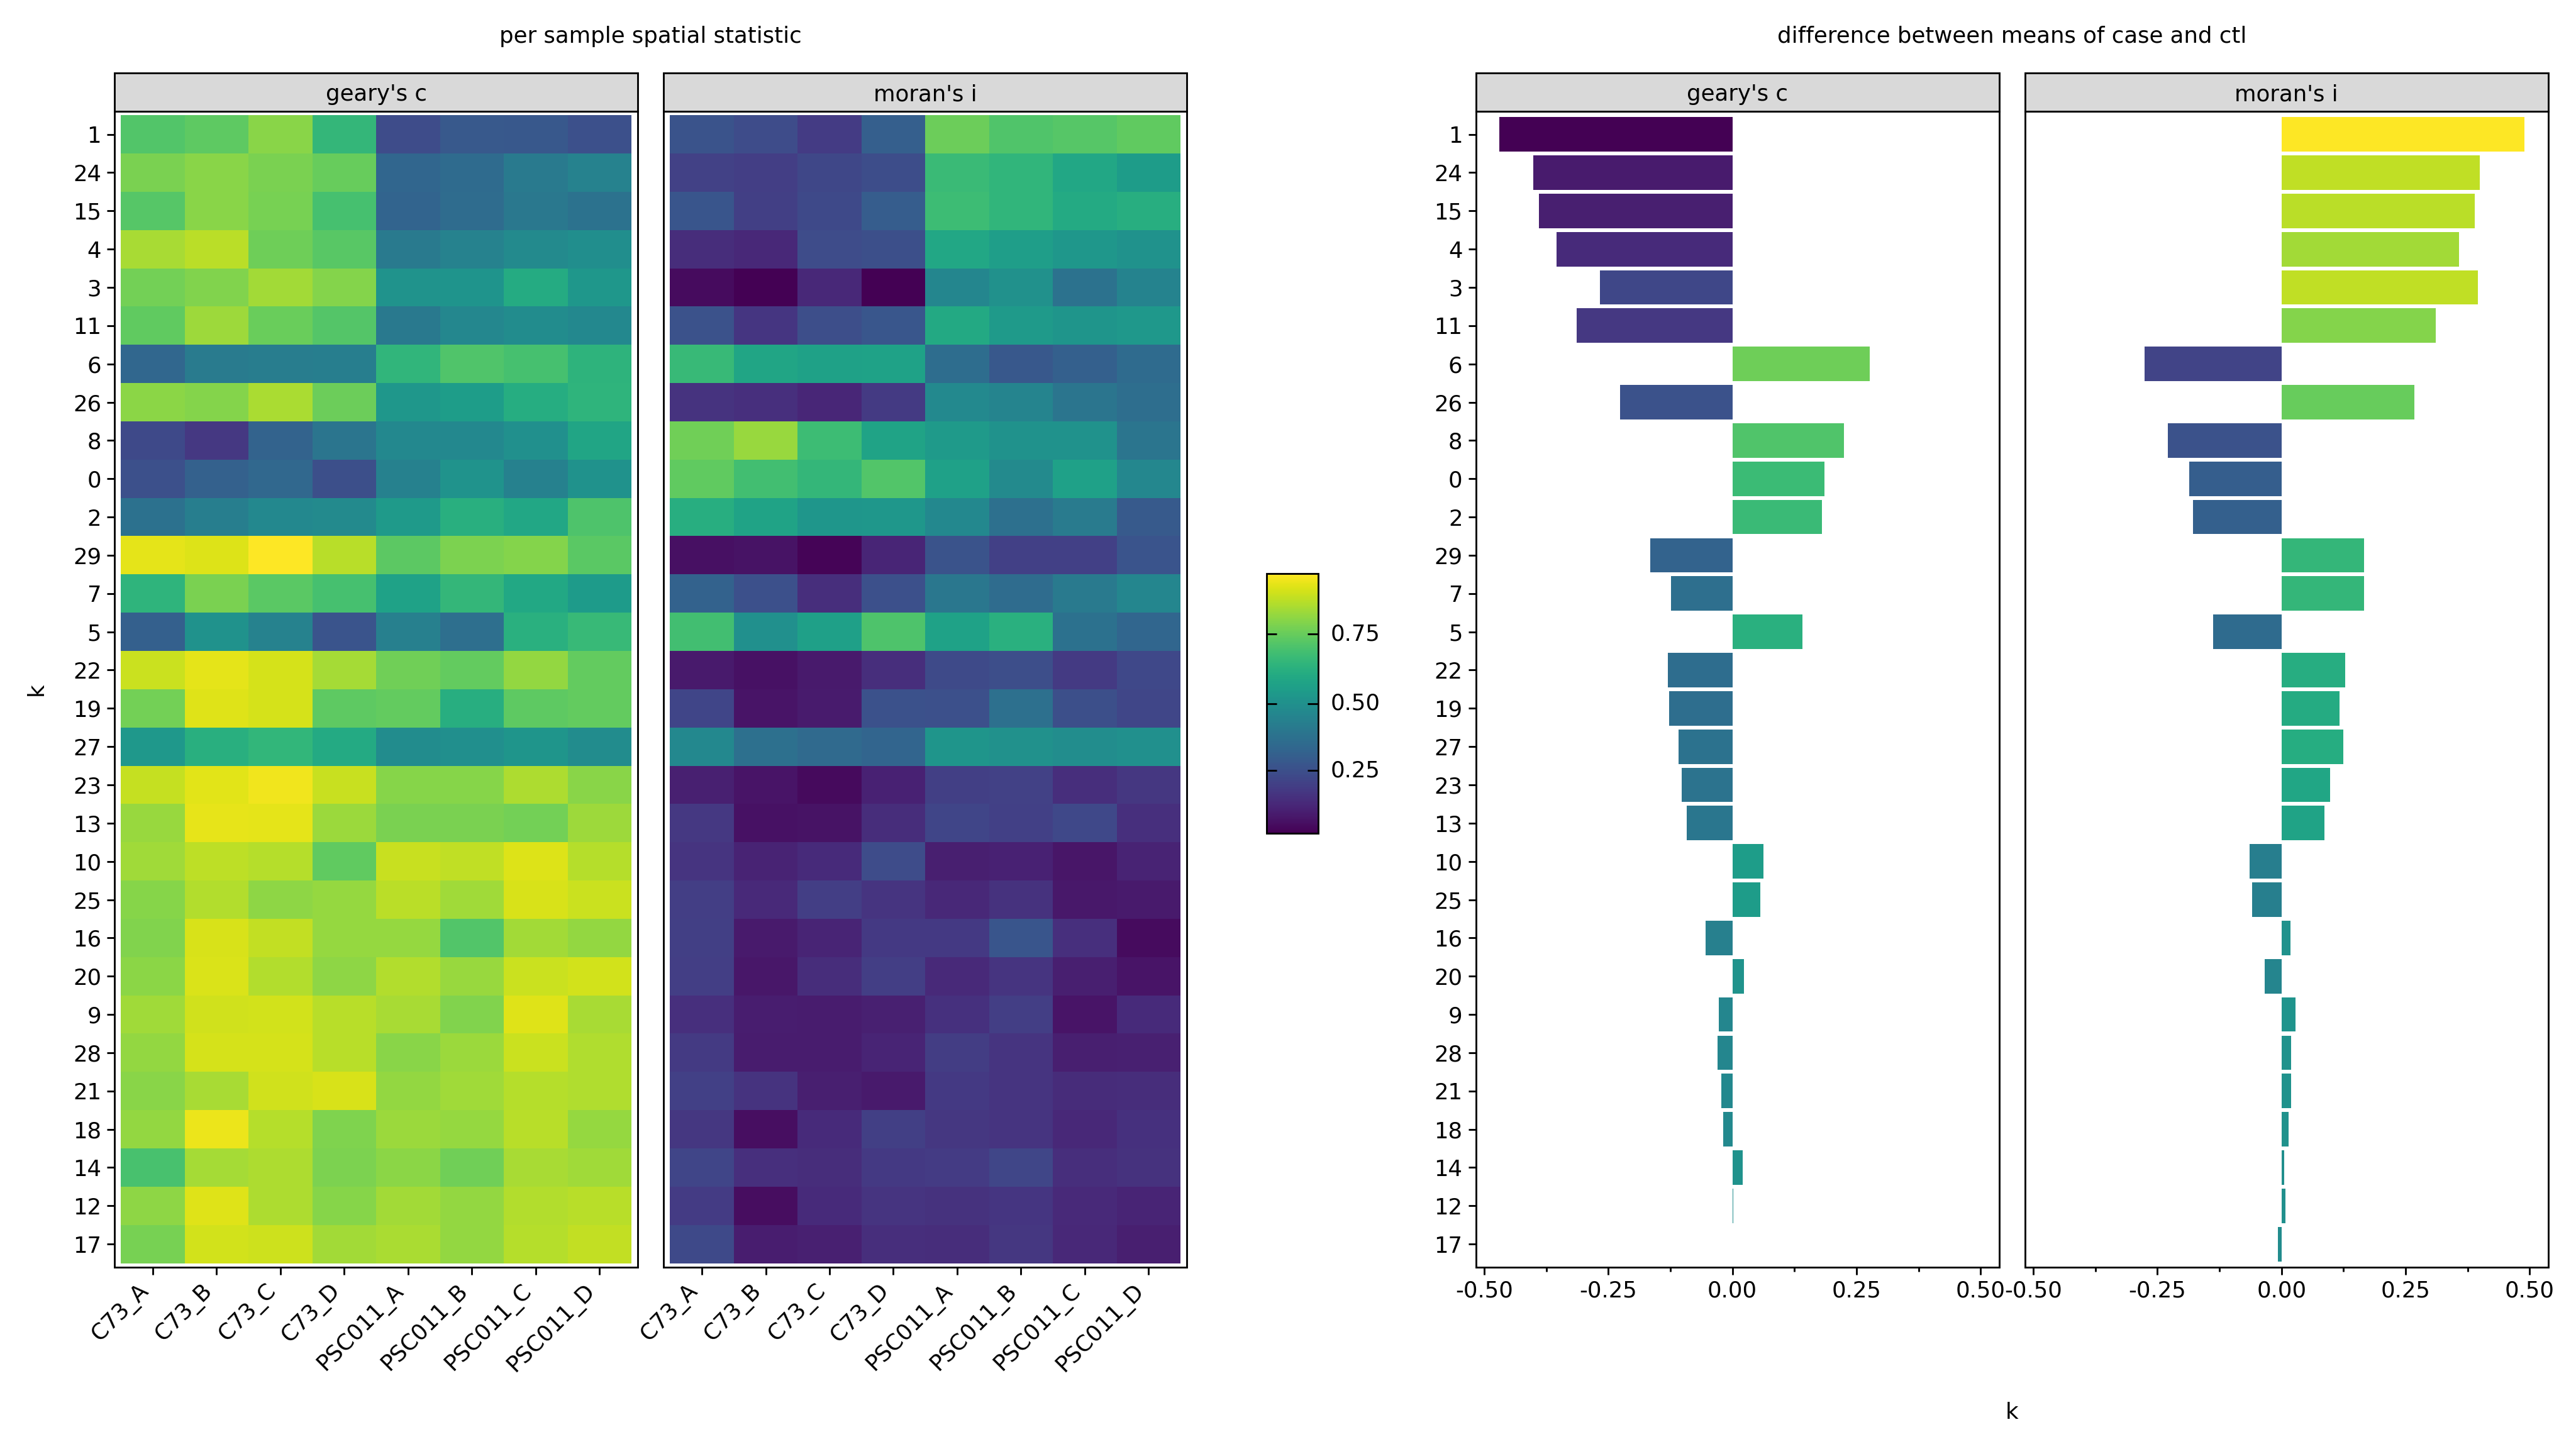

In [8]:
(sp_stat_pl & theme(figure_size=(16, 9))).show()  # ty:ignore[unsupported-operator]

we can see that factor 4 has a strong case-specific profile (positive beta) and shows noticeable differences
between case and control in its spatial statistics, so we plot its distributions below:

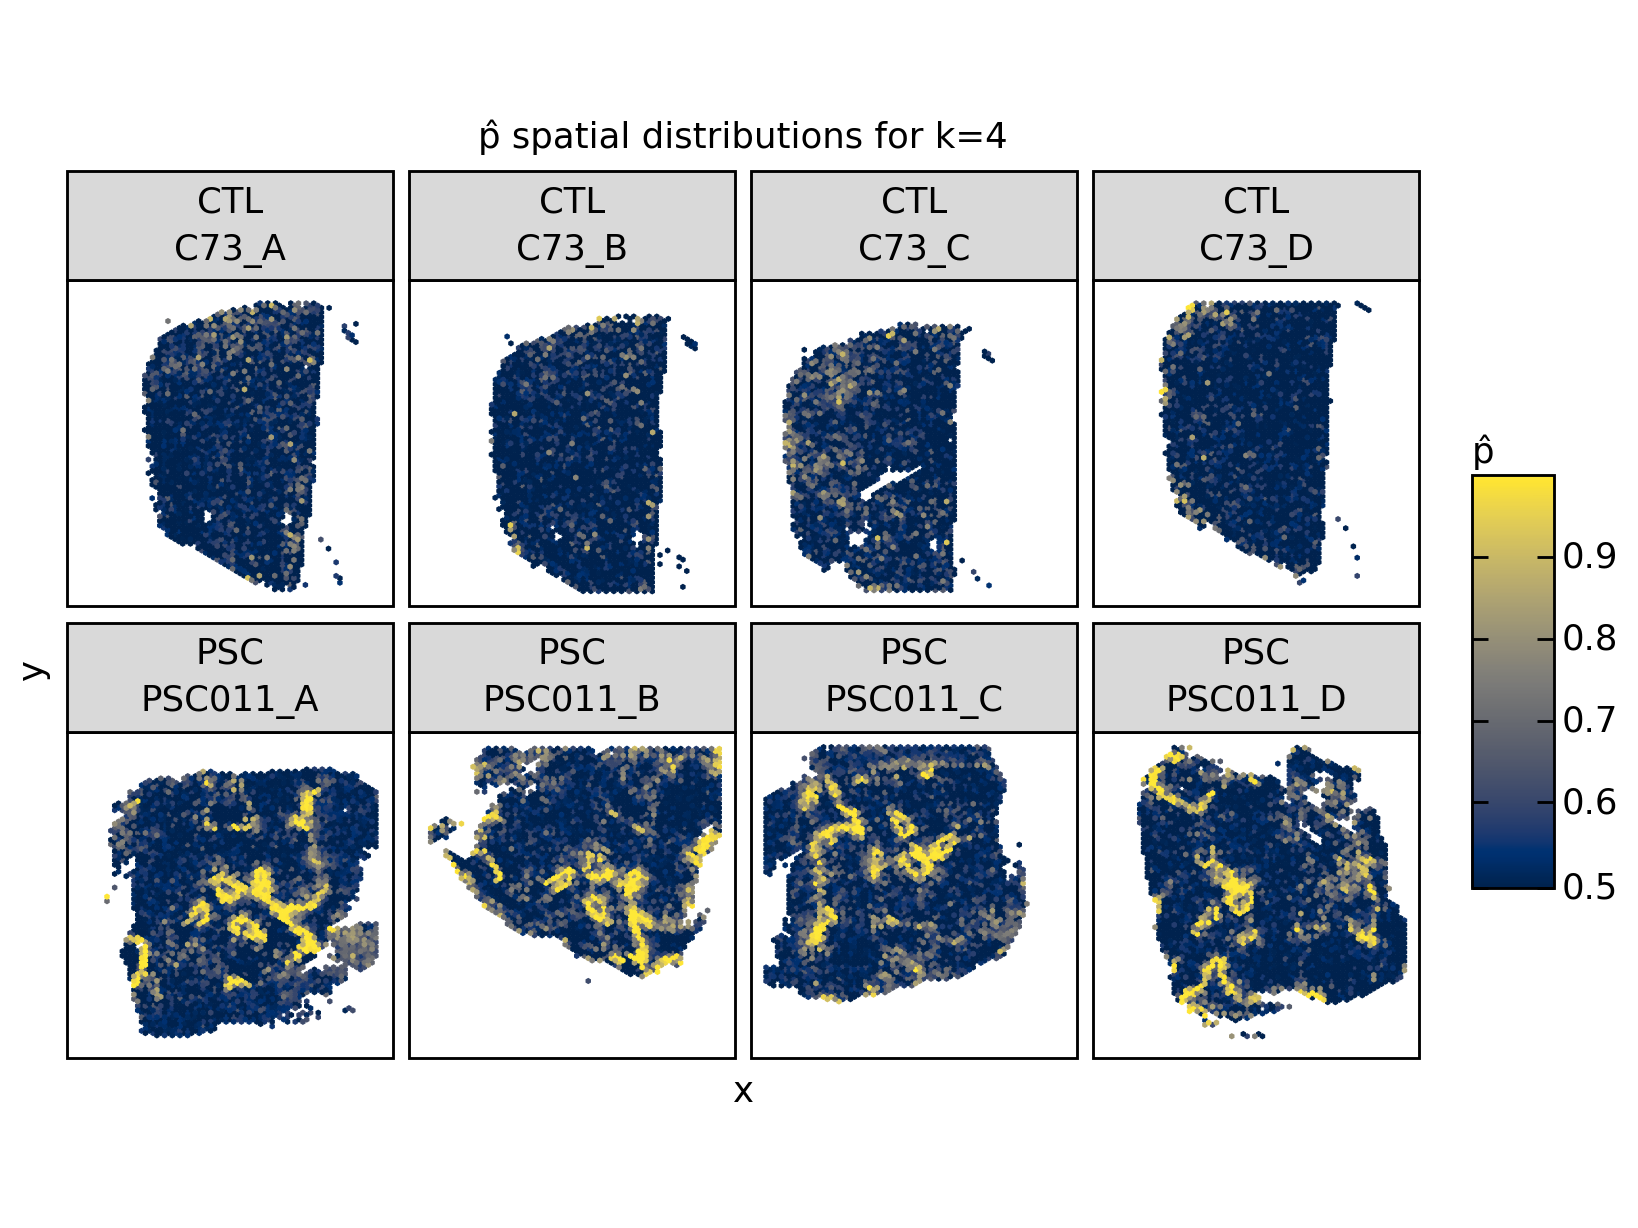

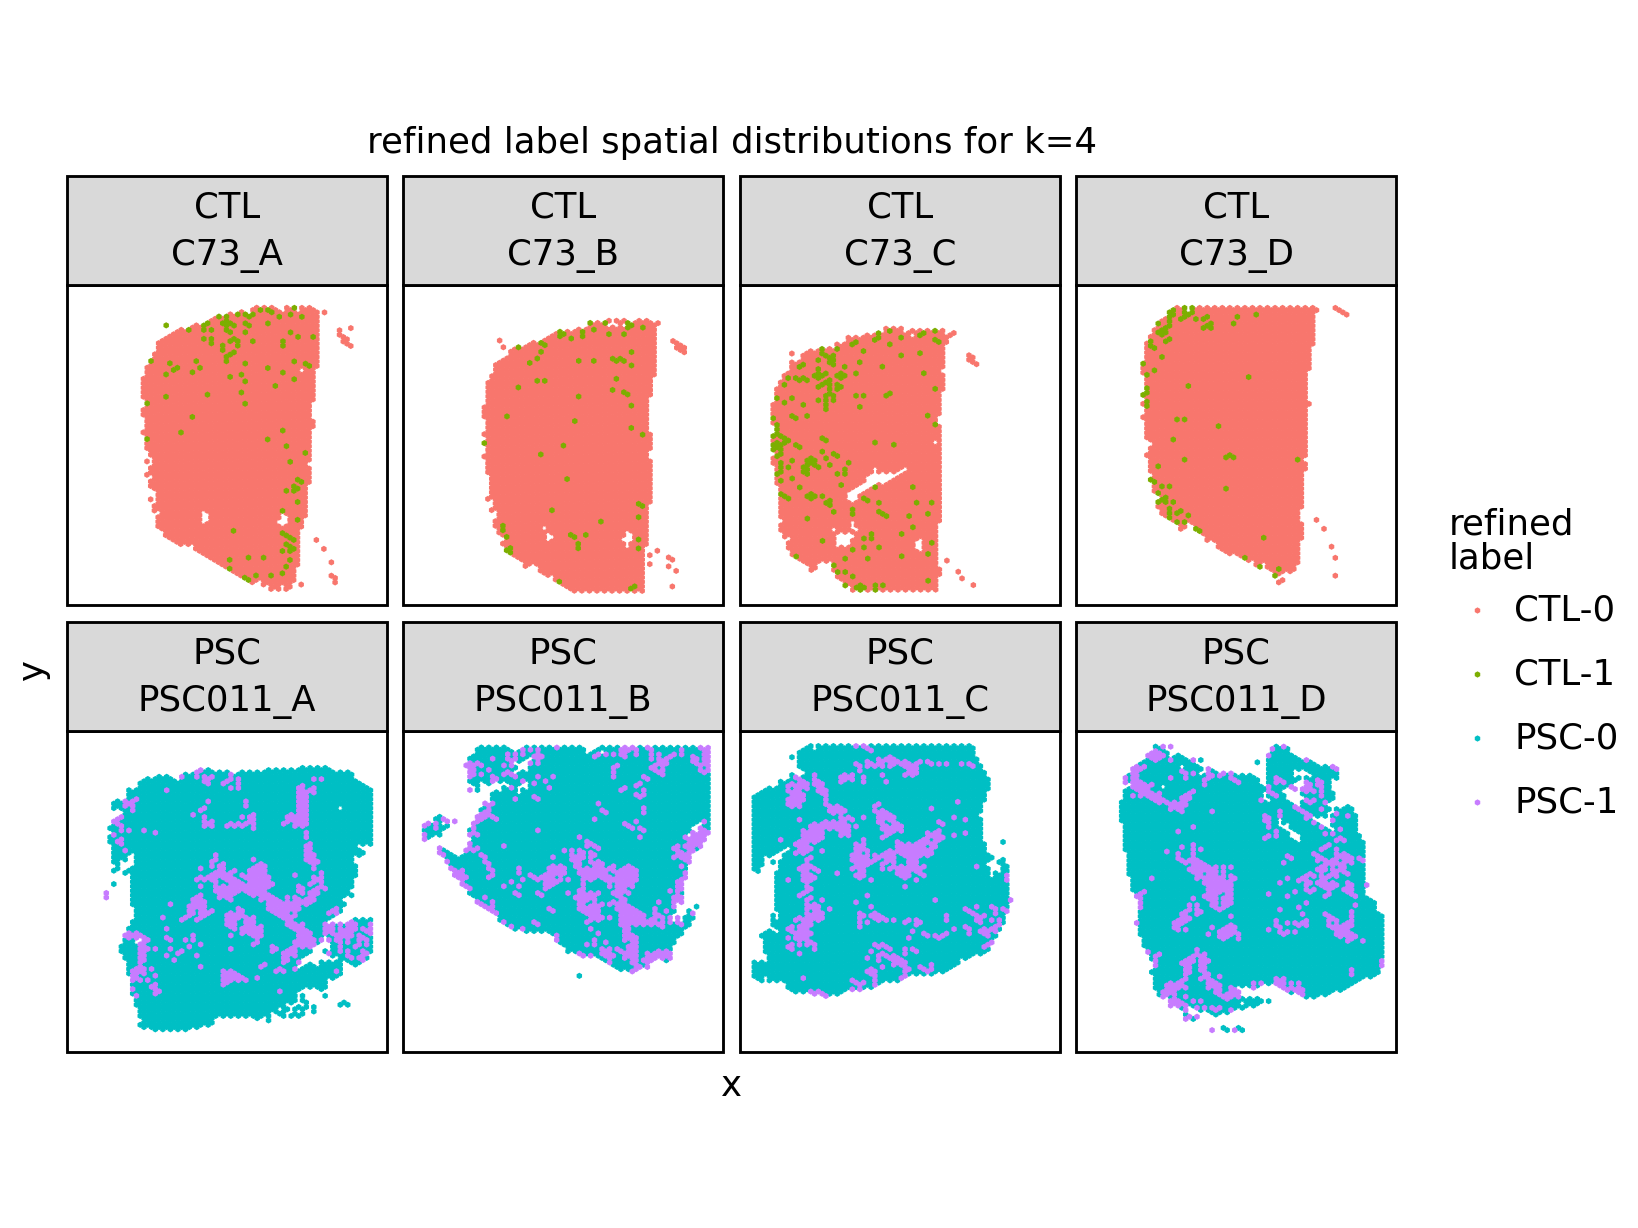

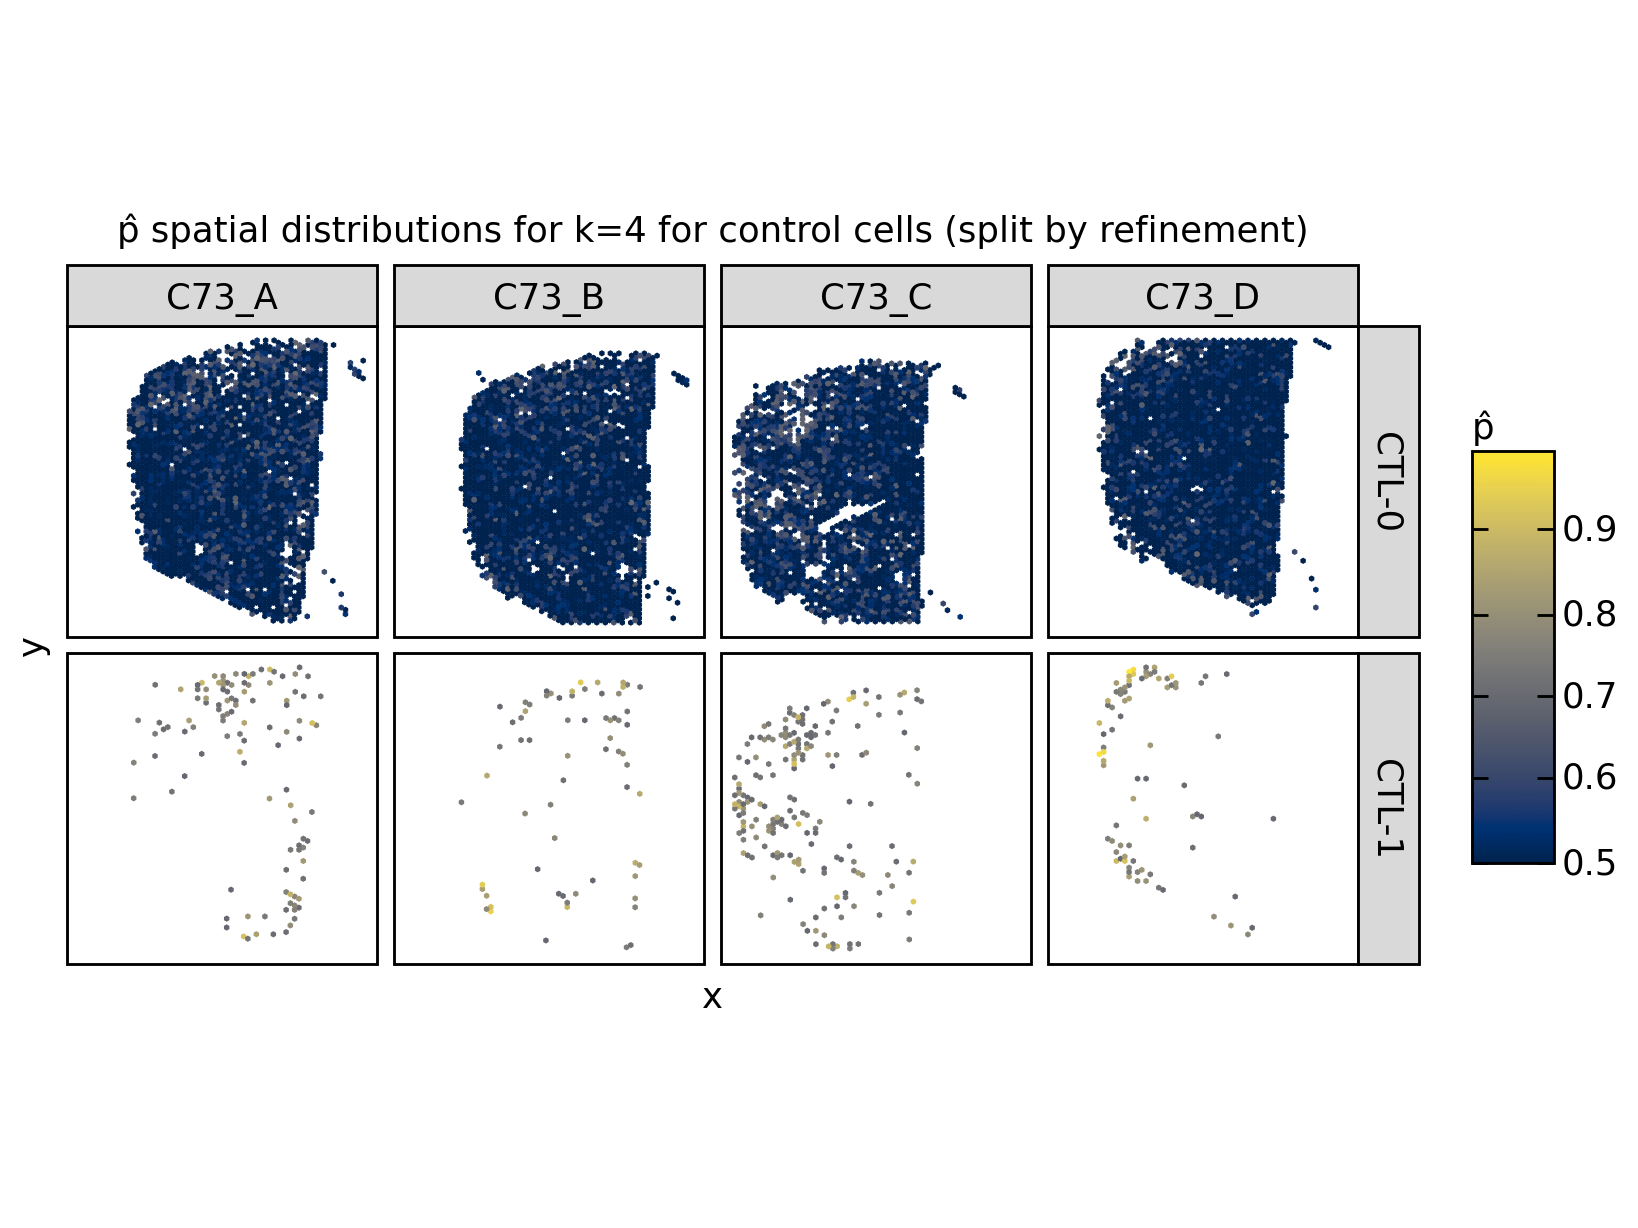

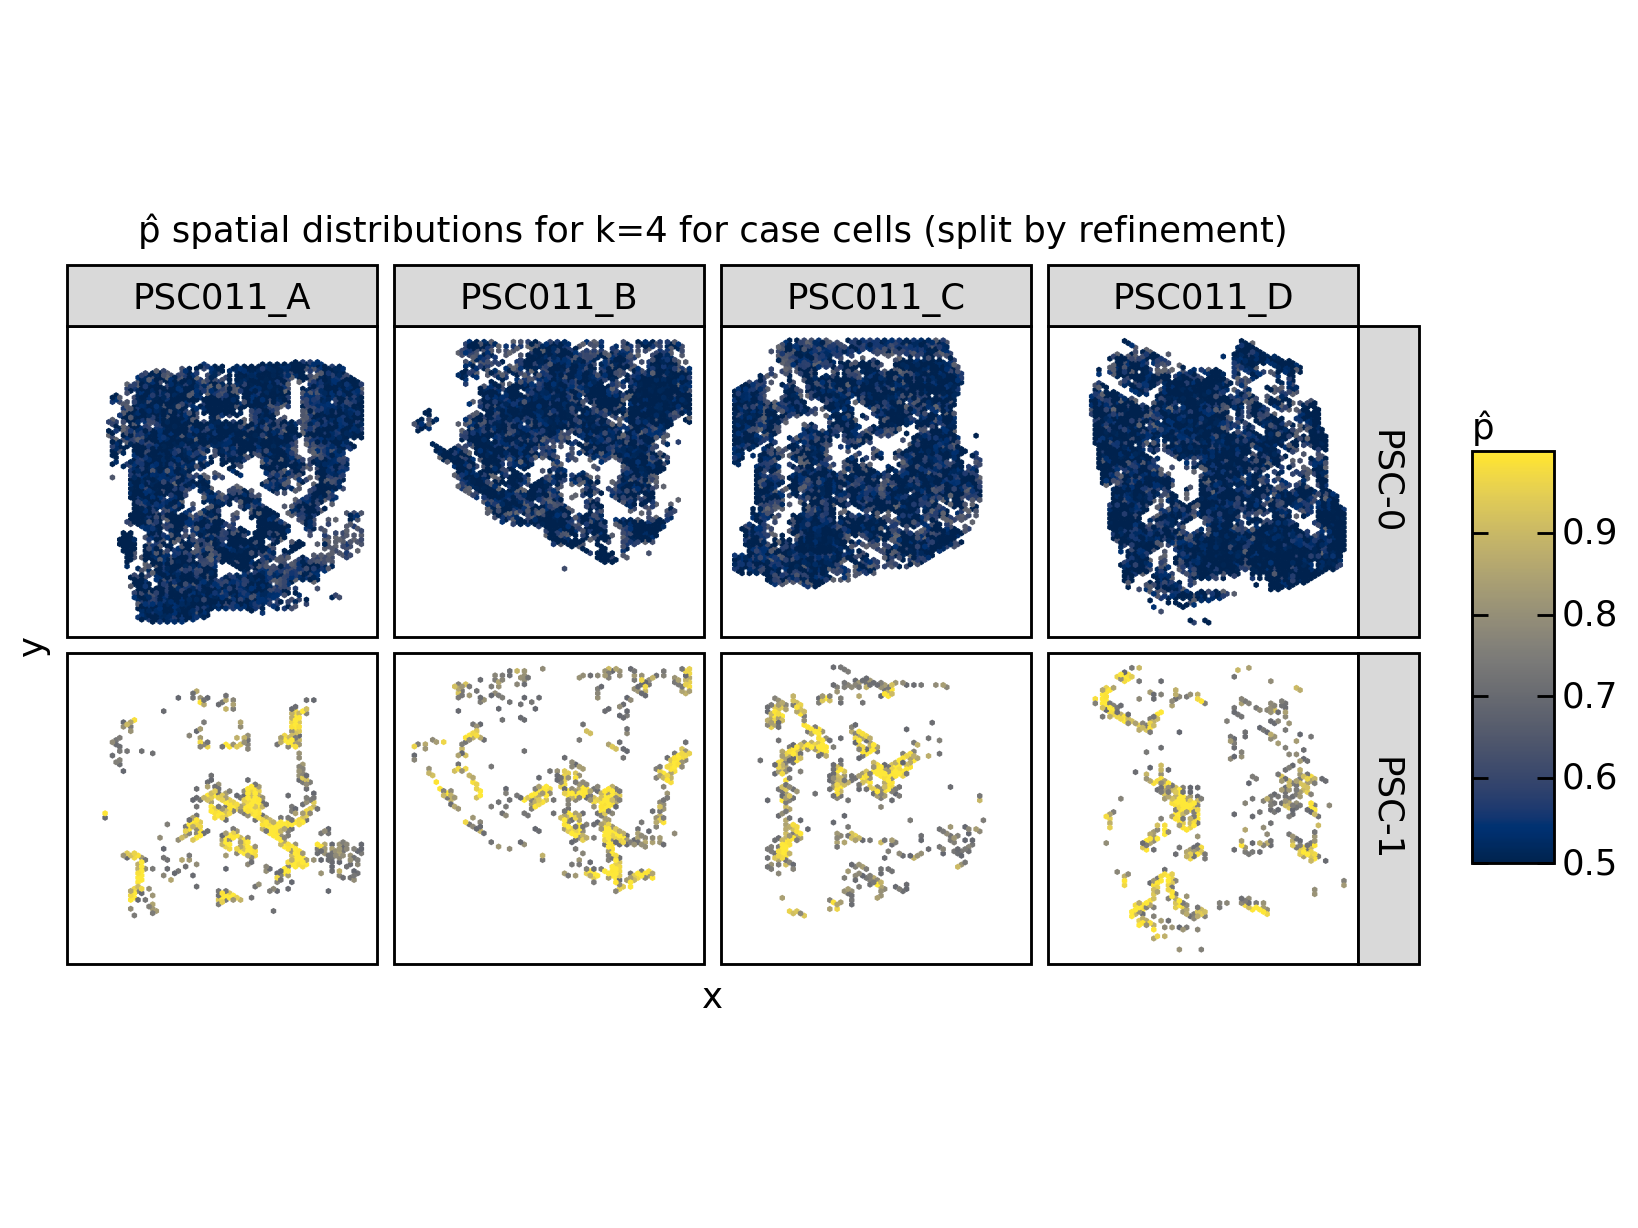

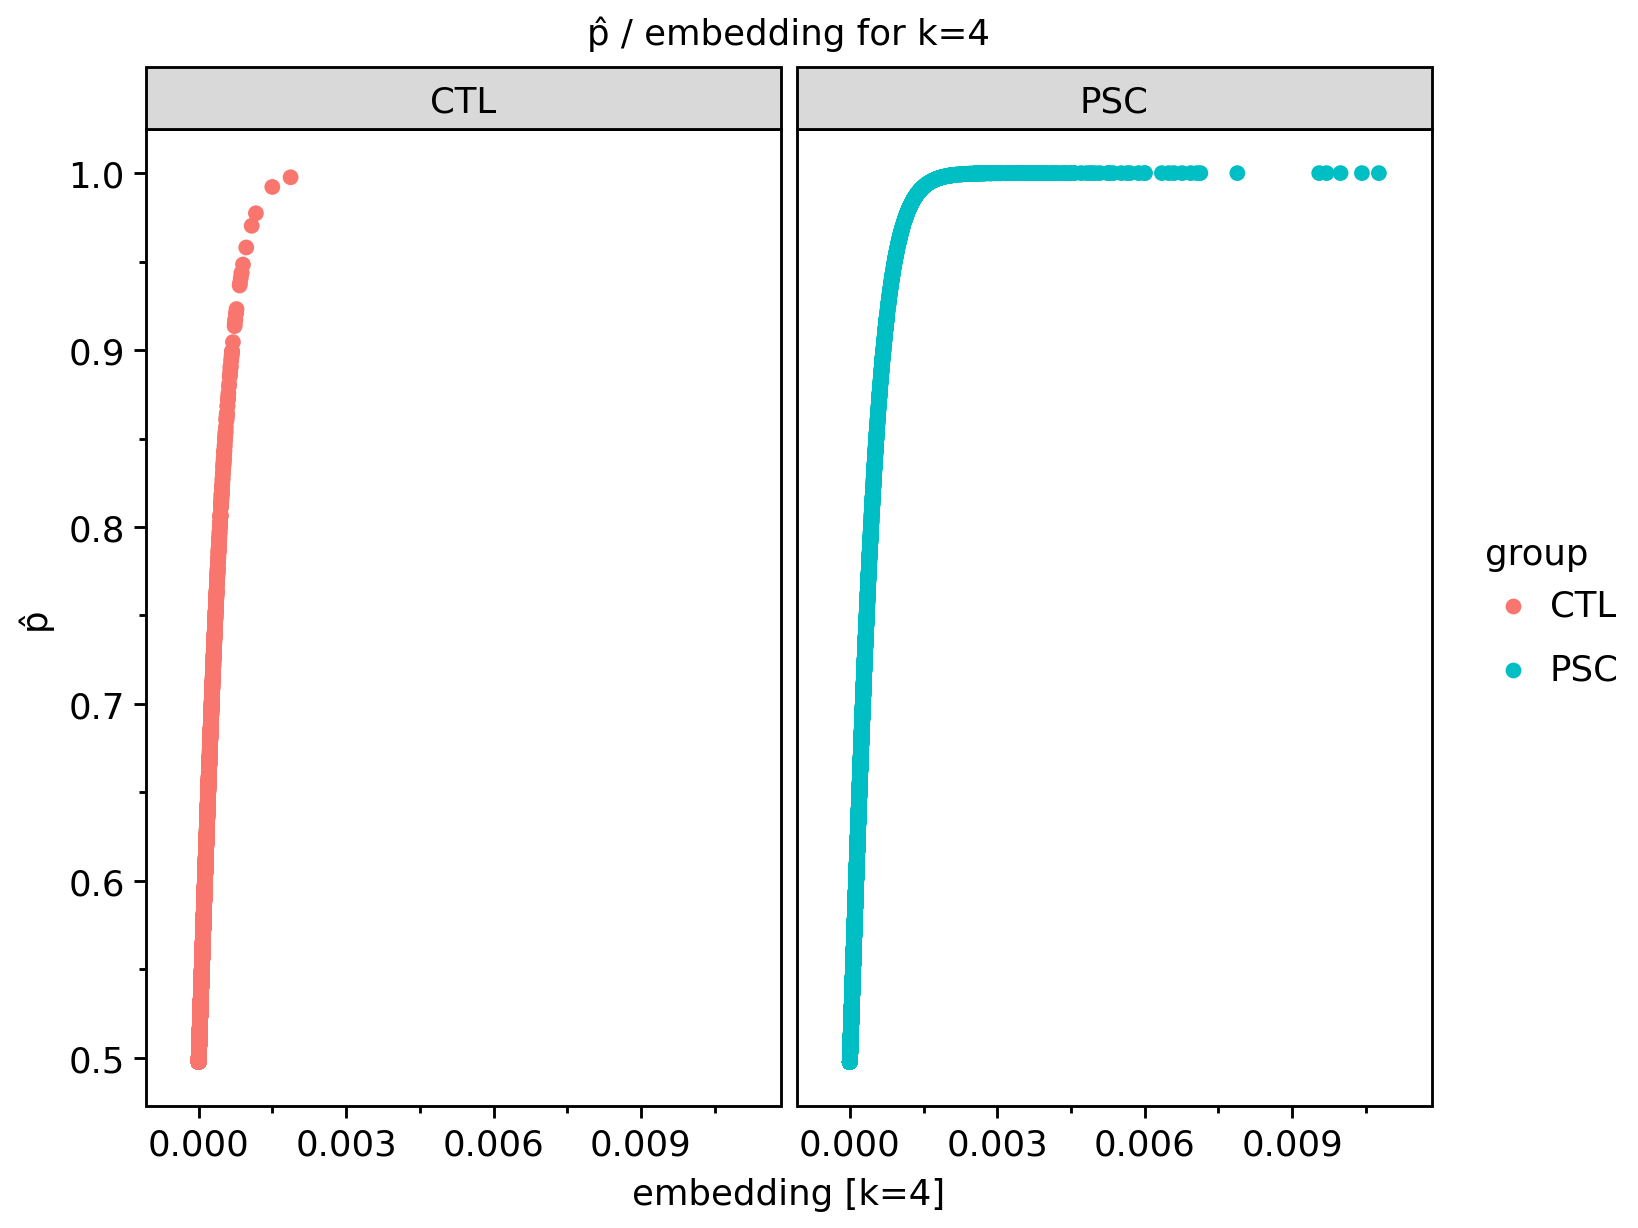

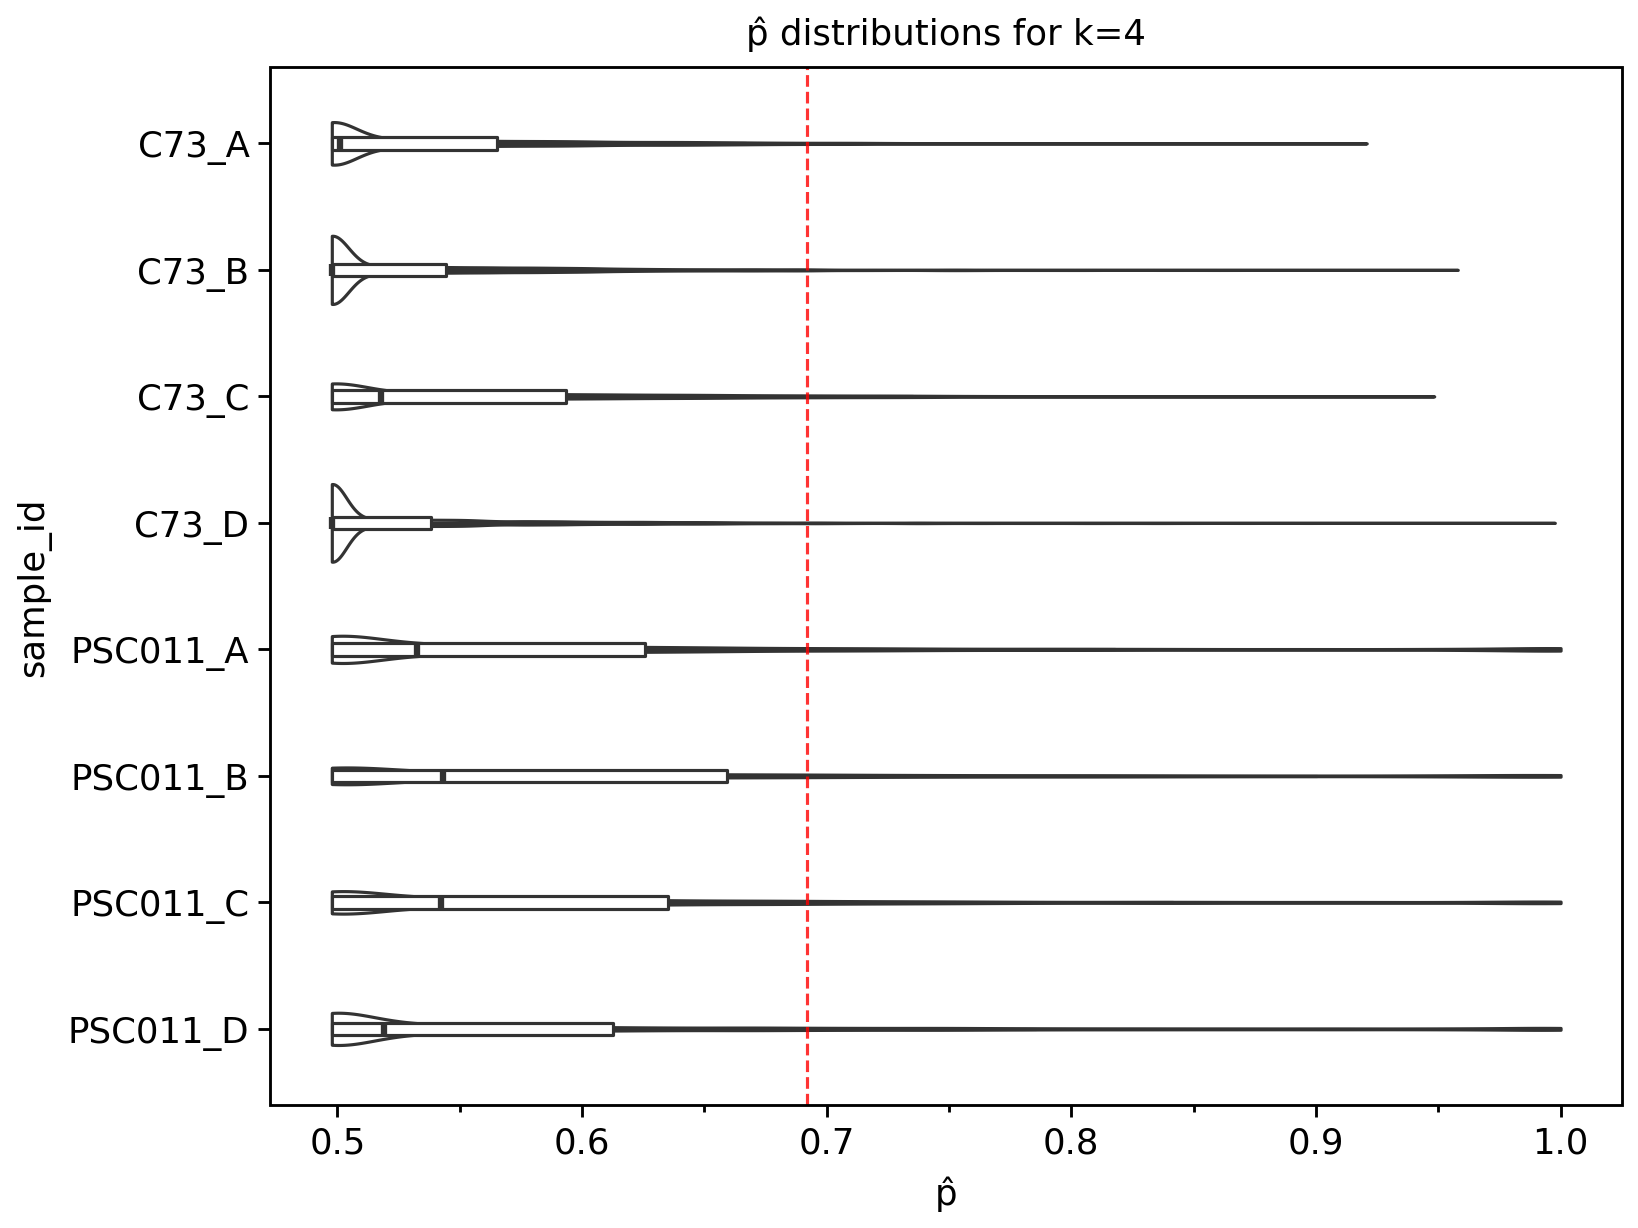

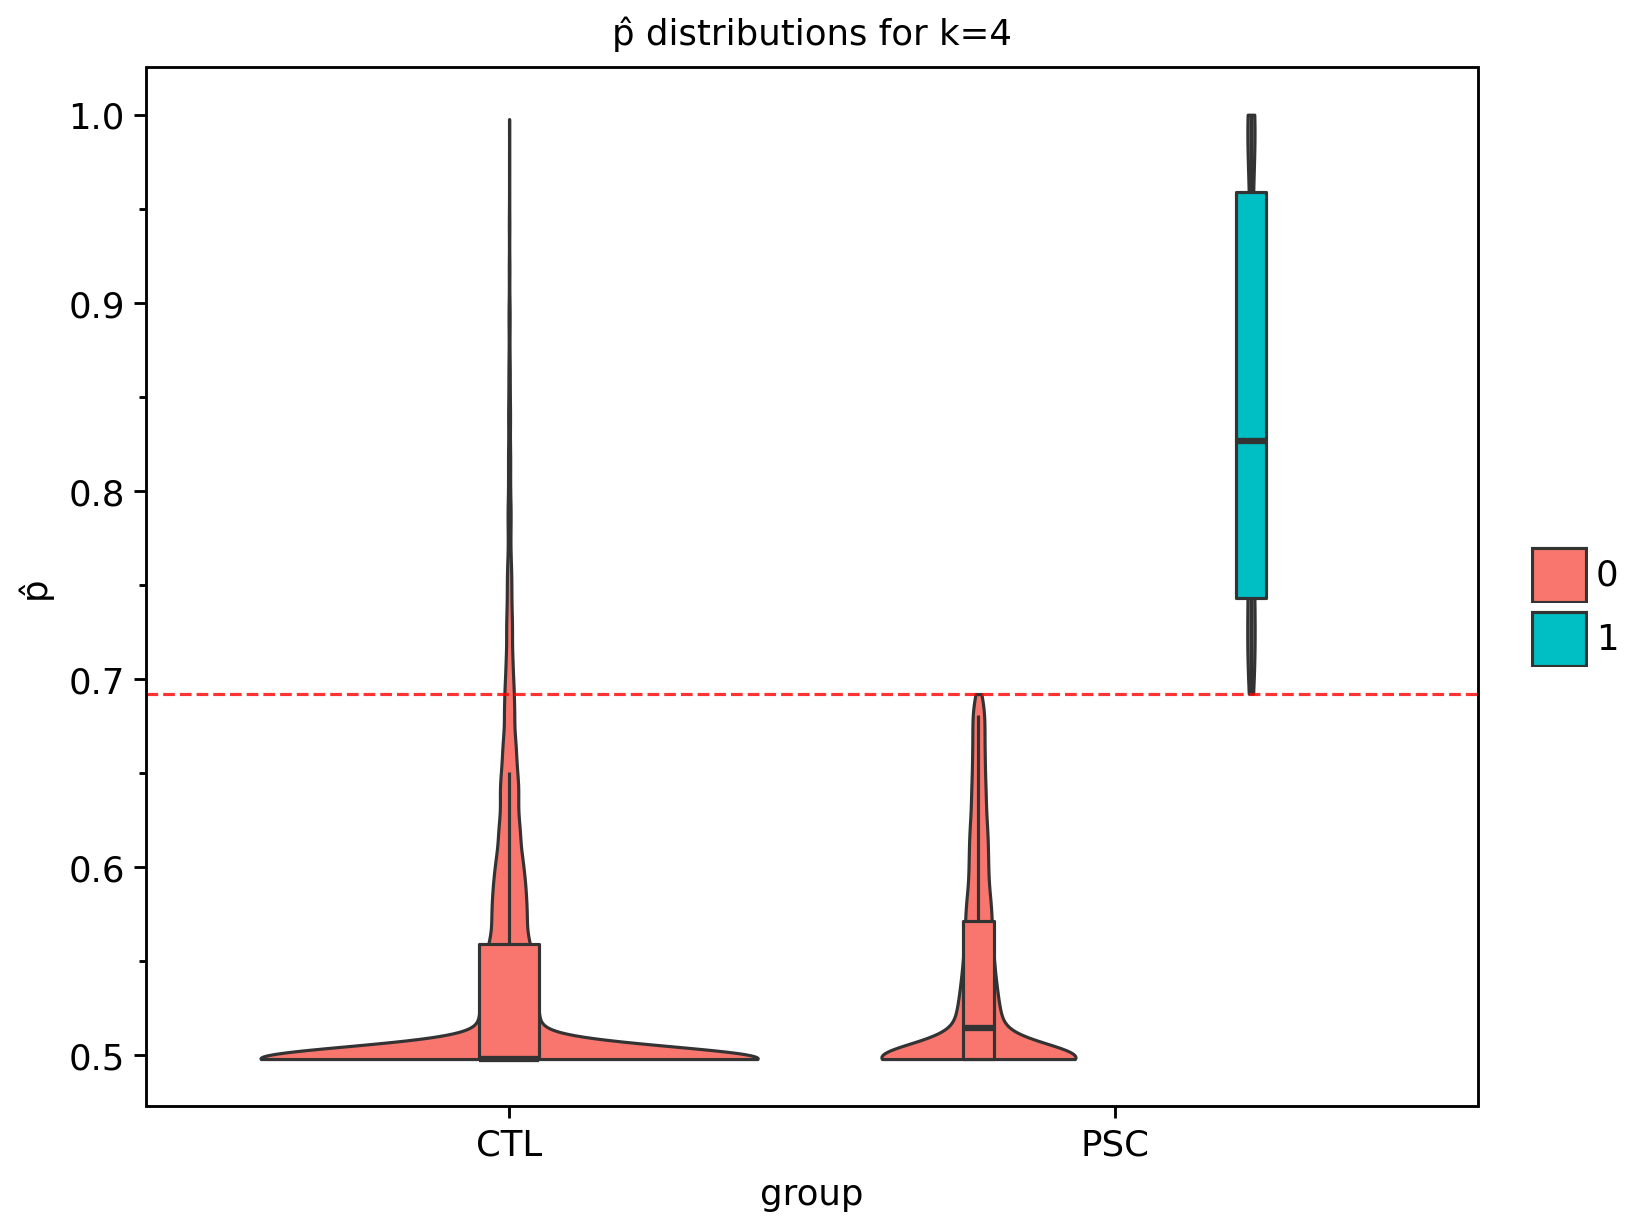

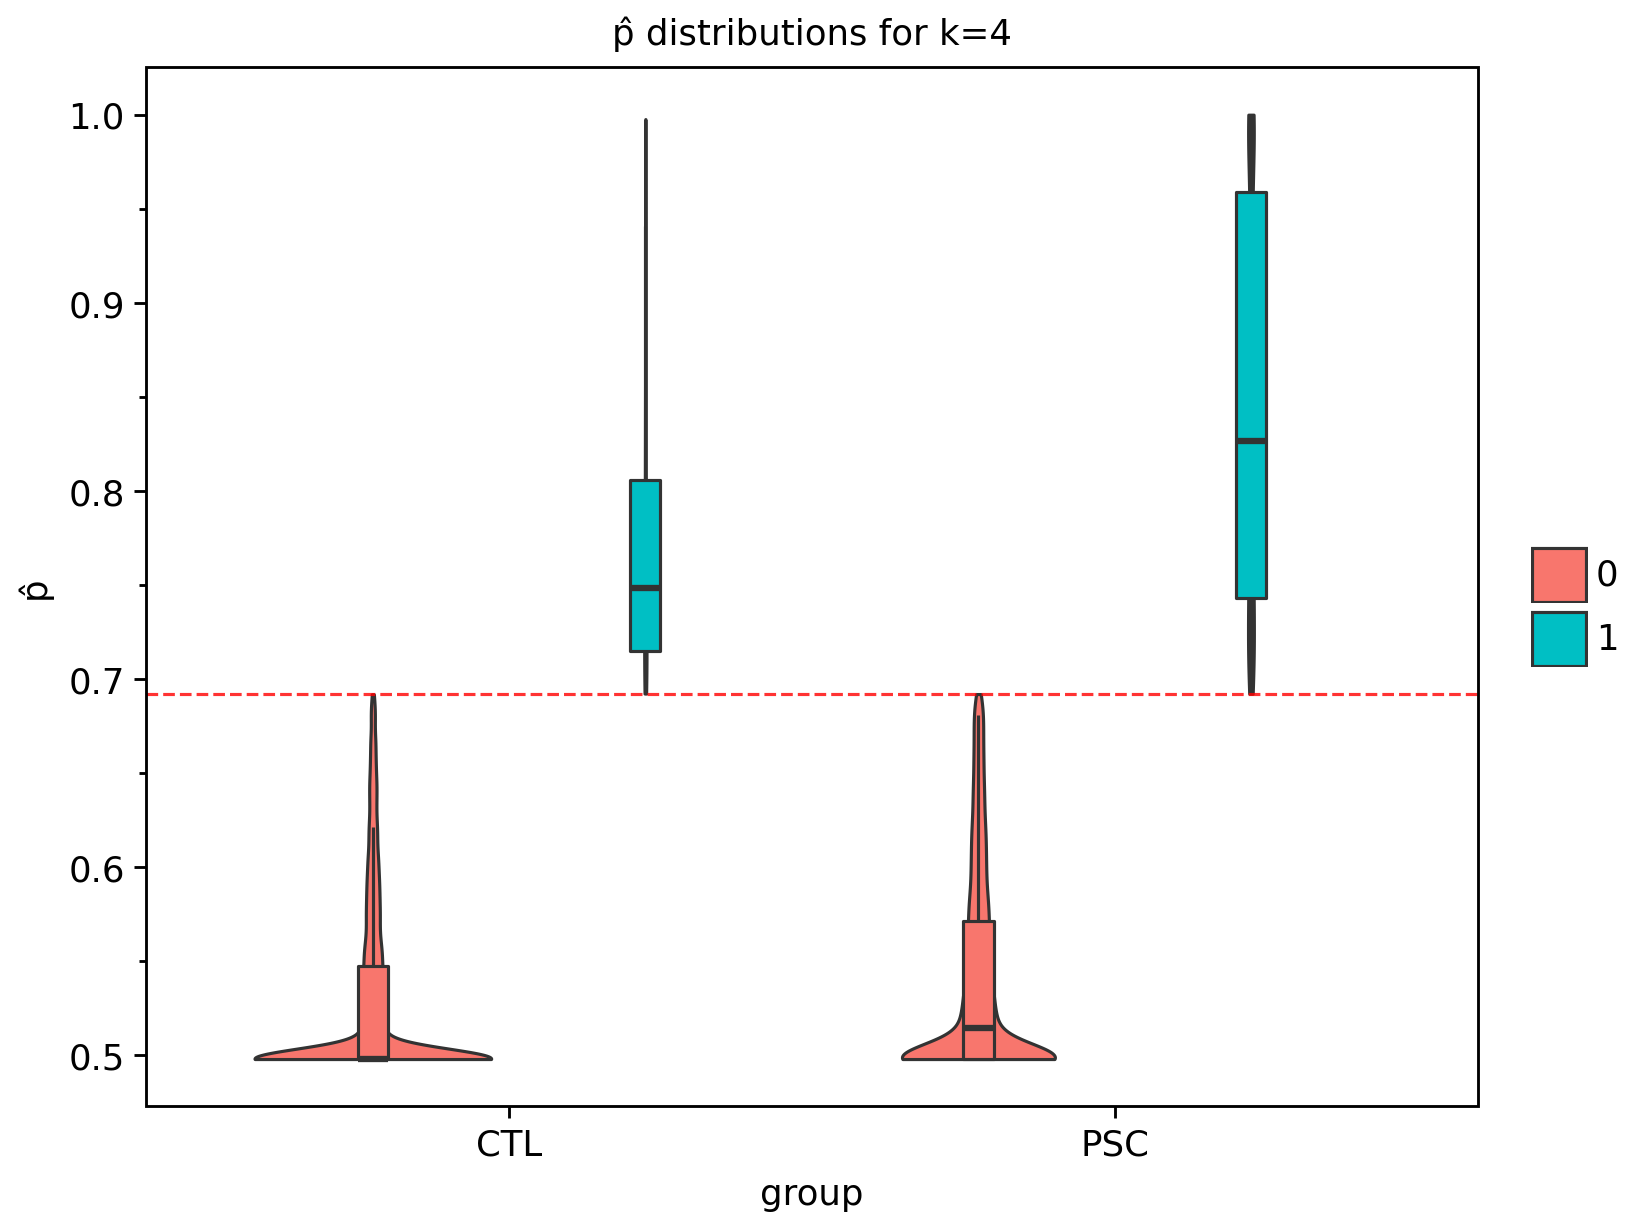

In [9]:
for p in pl_help(psc, 4).values():
    p.show()

we can see that factor 6 has a strong control-specific profile (negative beta) and shows noticeable differences
between case and control in its spatial statistics, so we plot its distributions below:

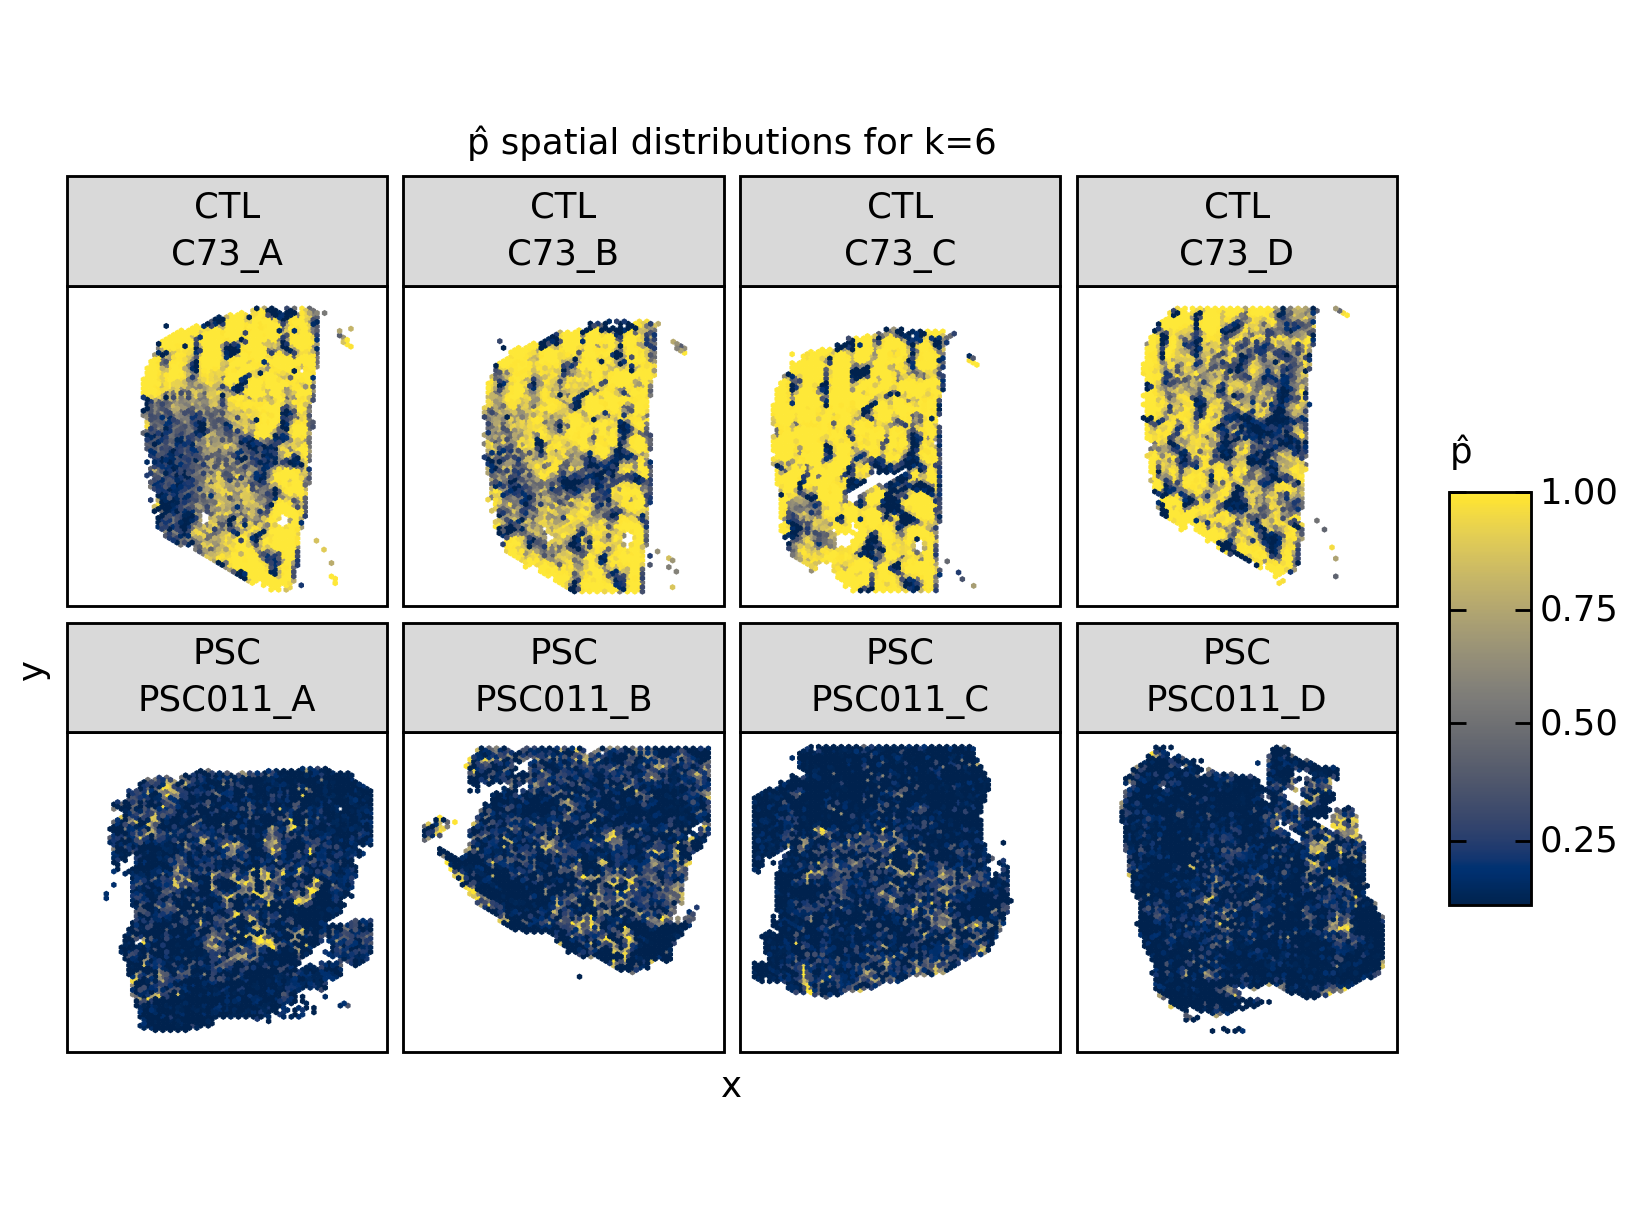

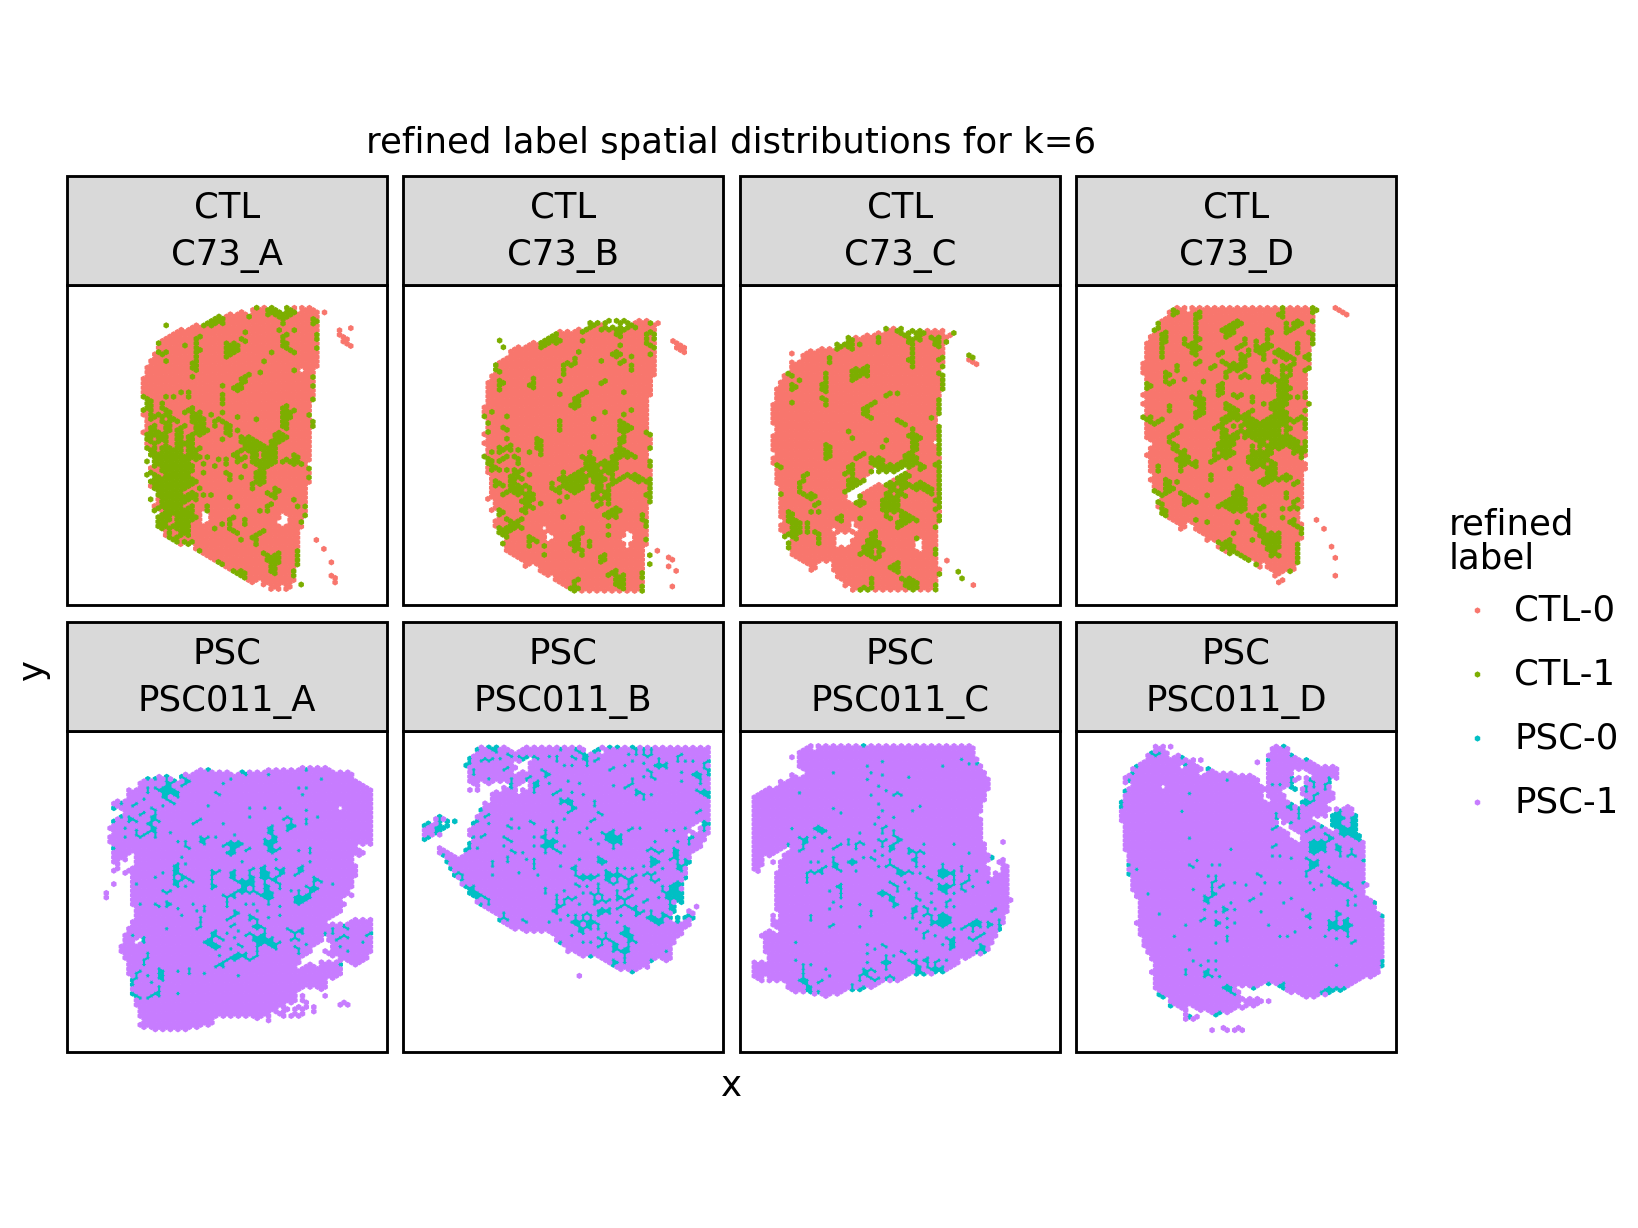

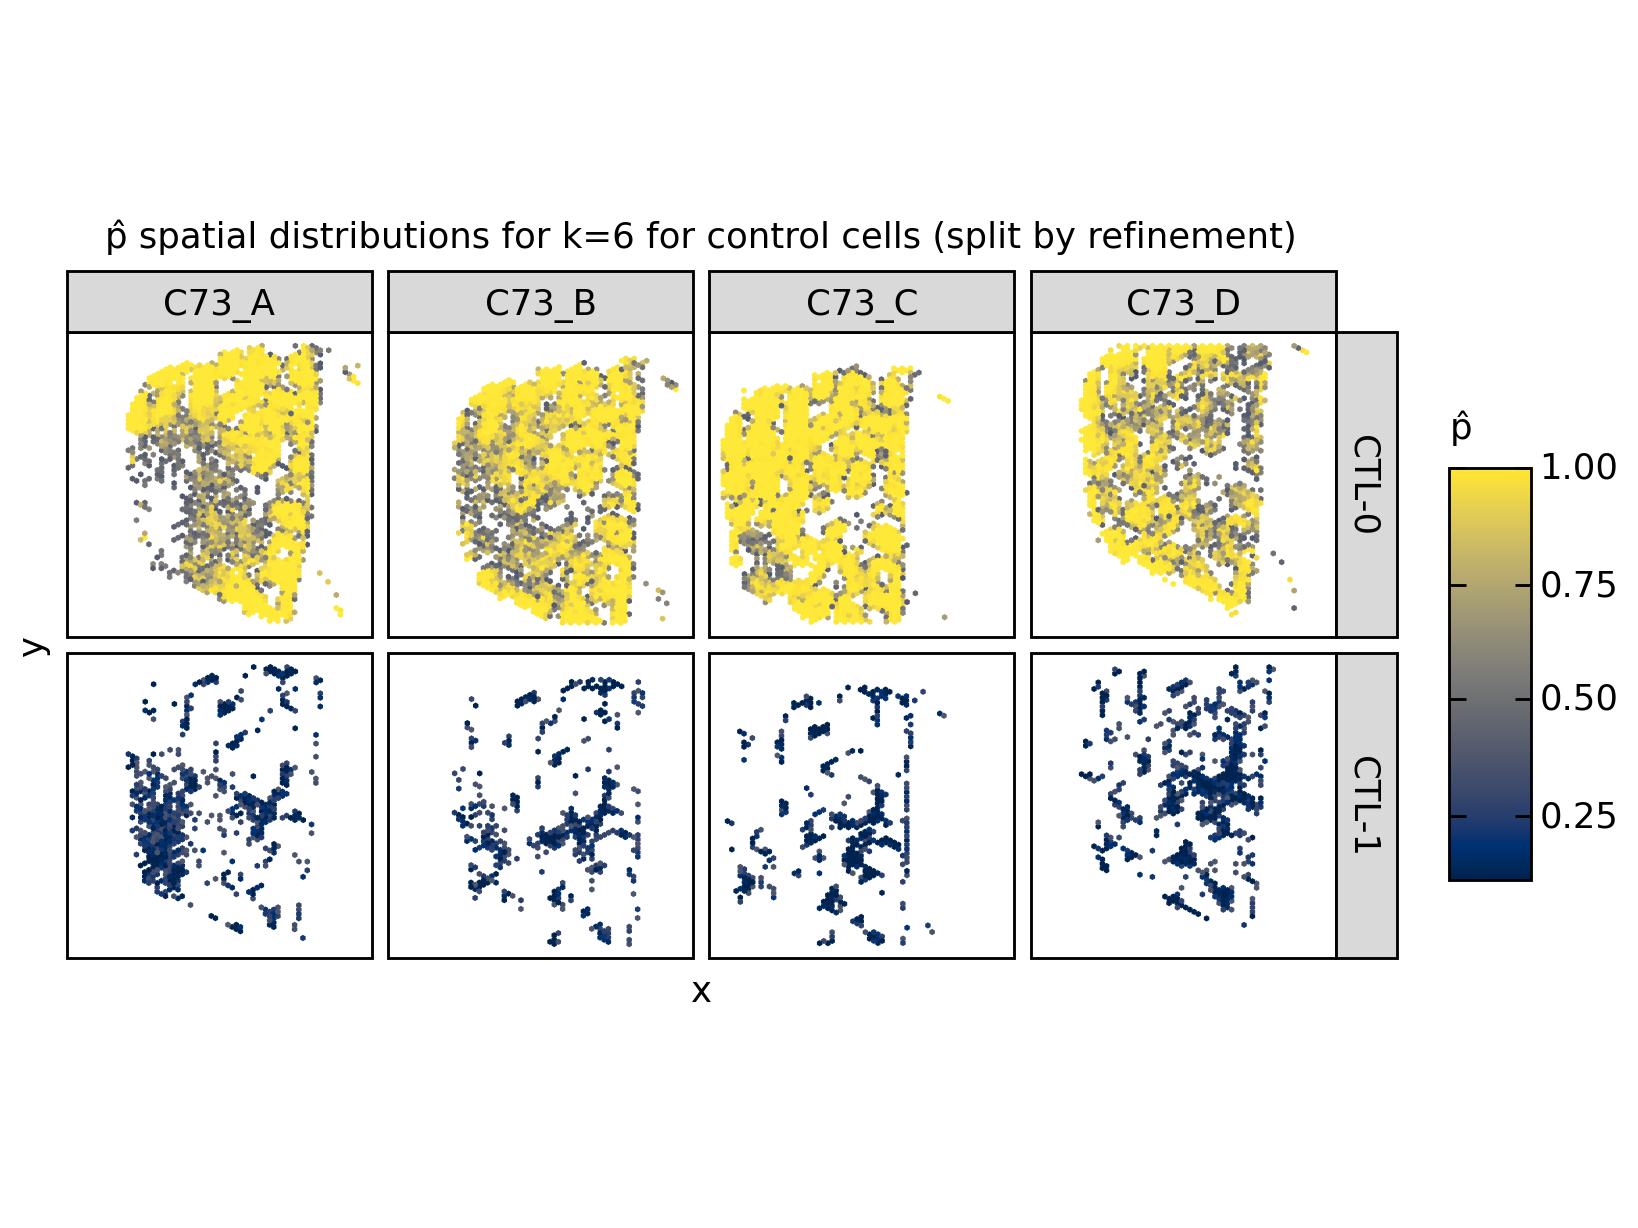

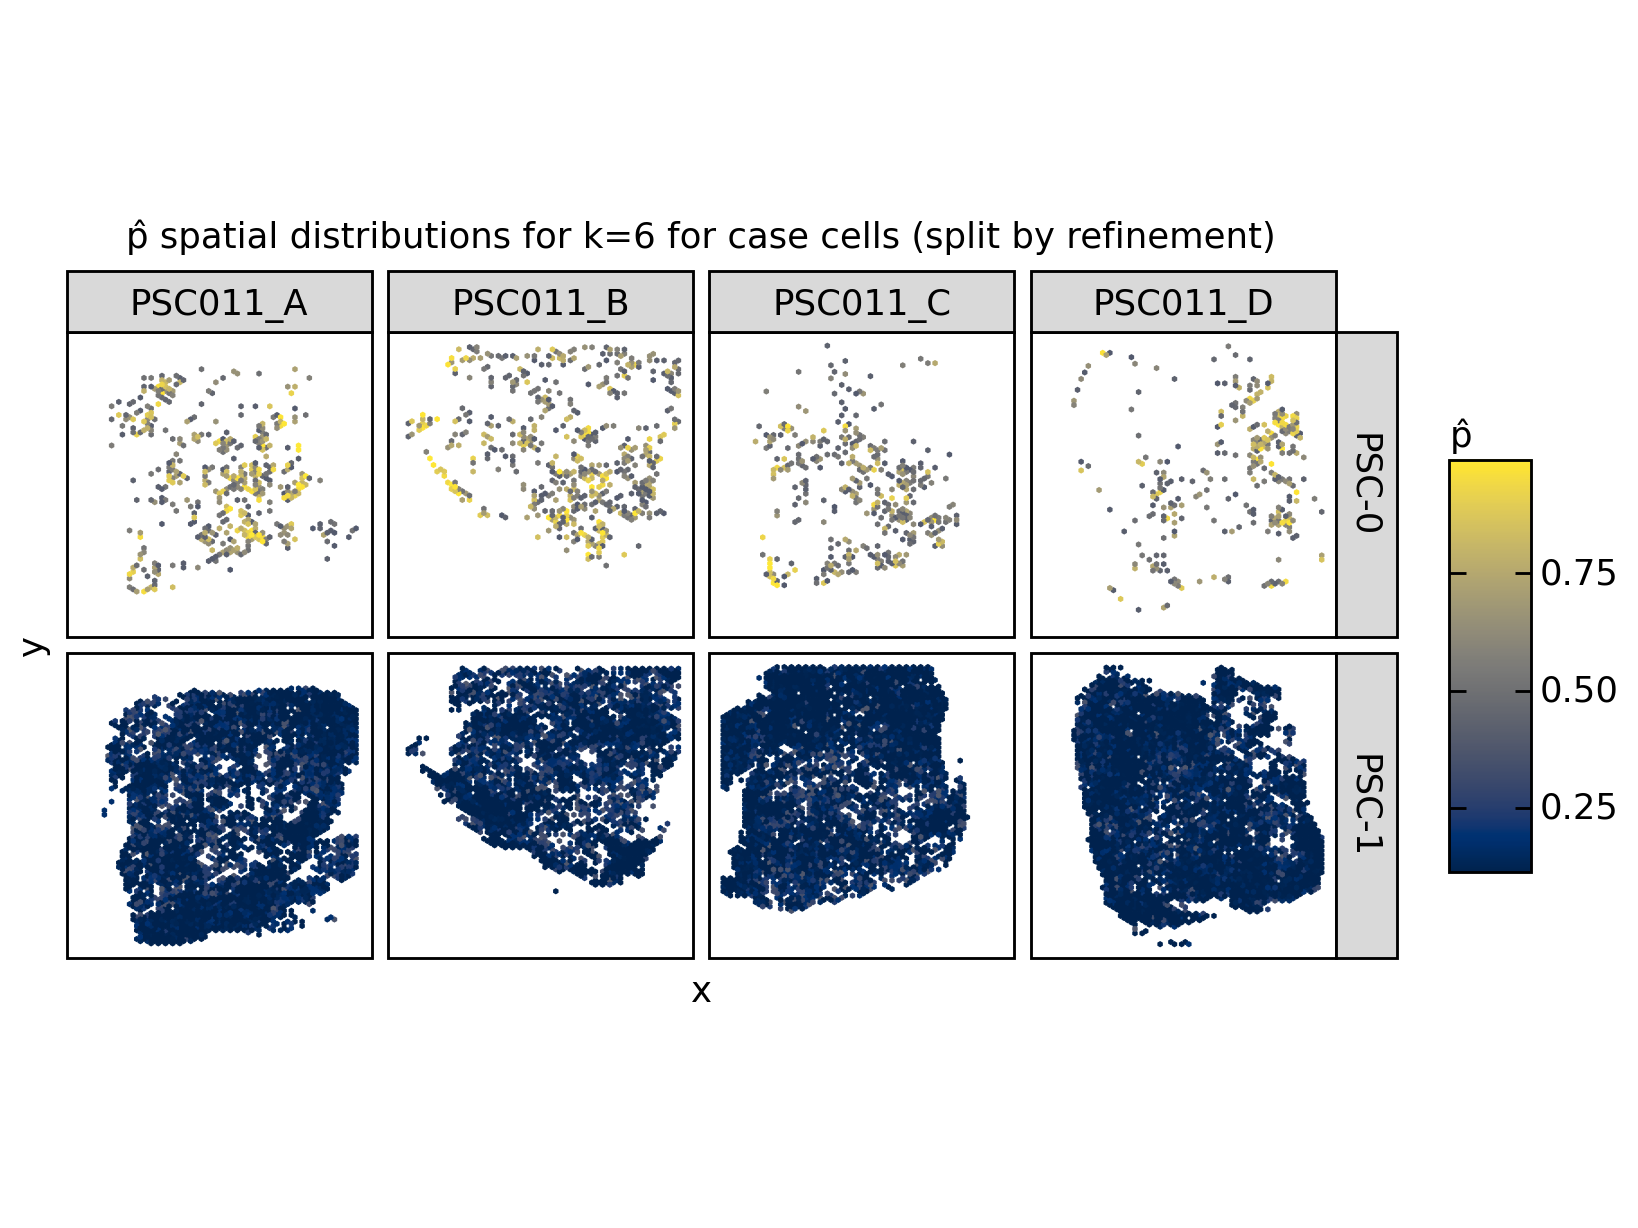

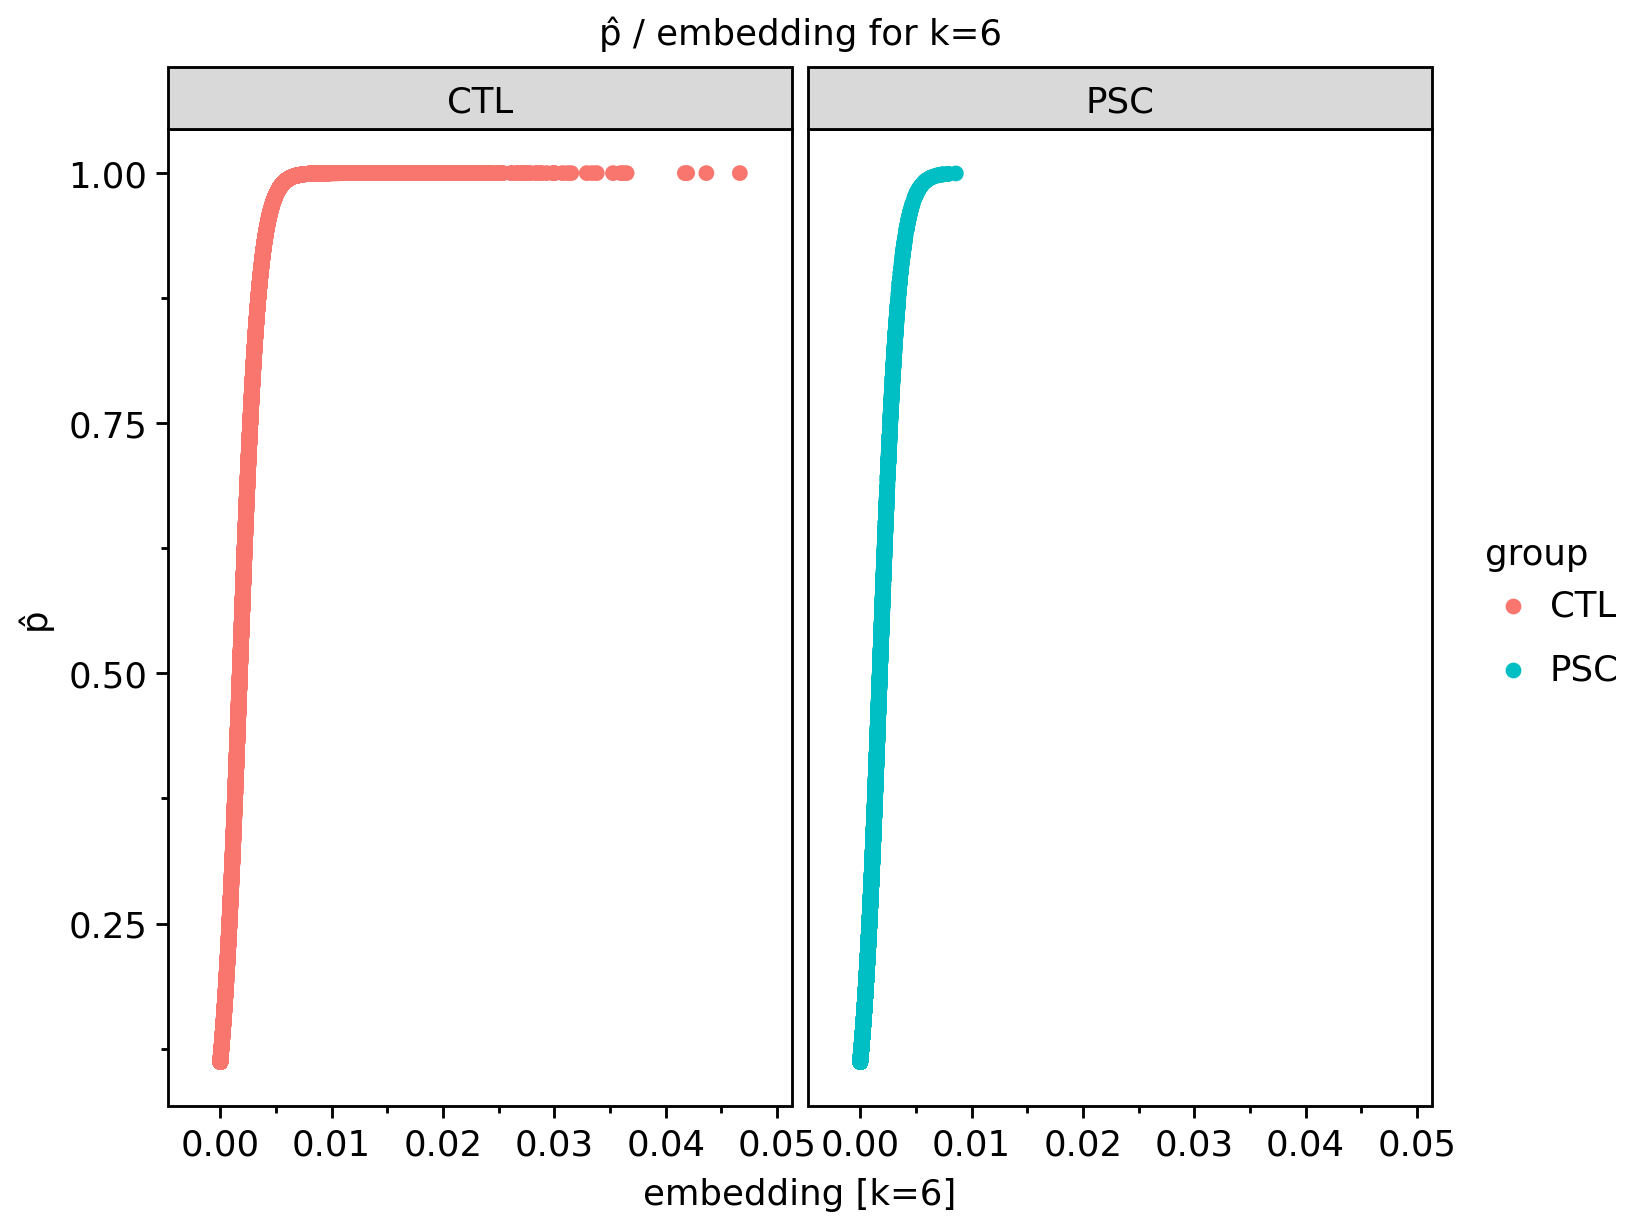

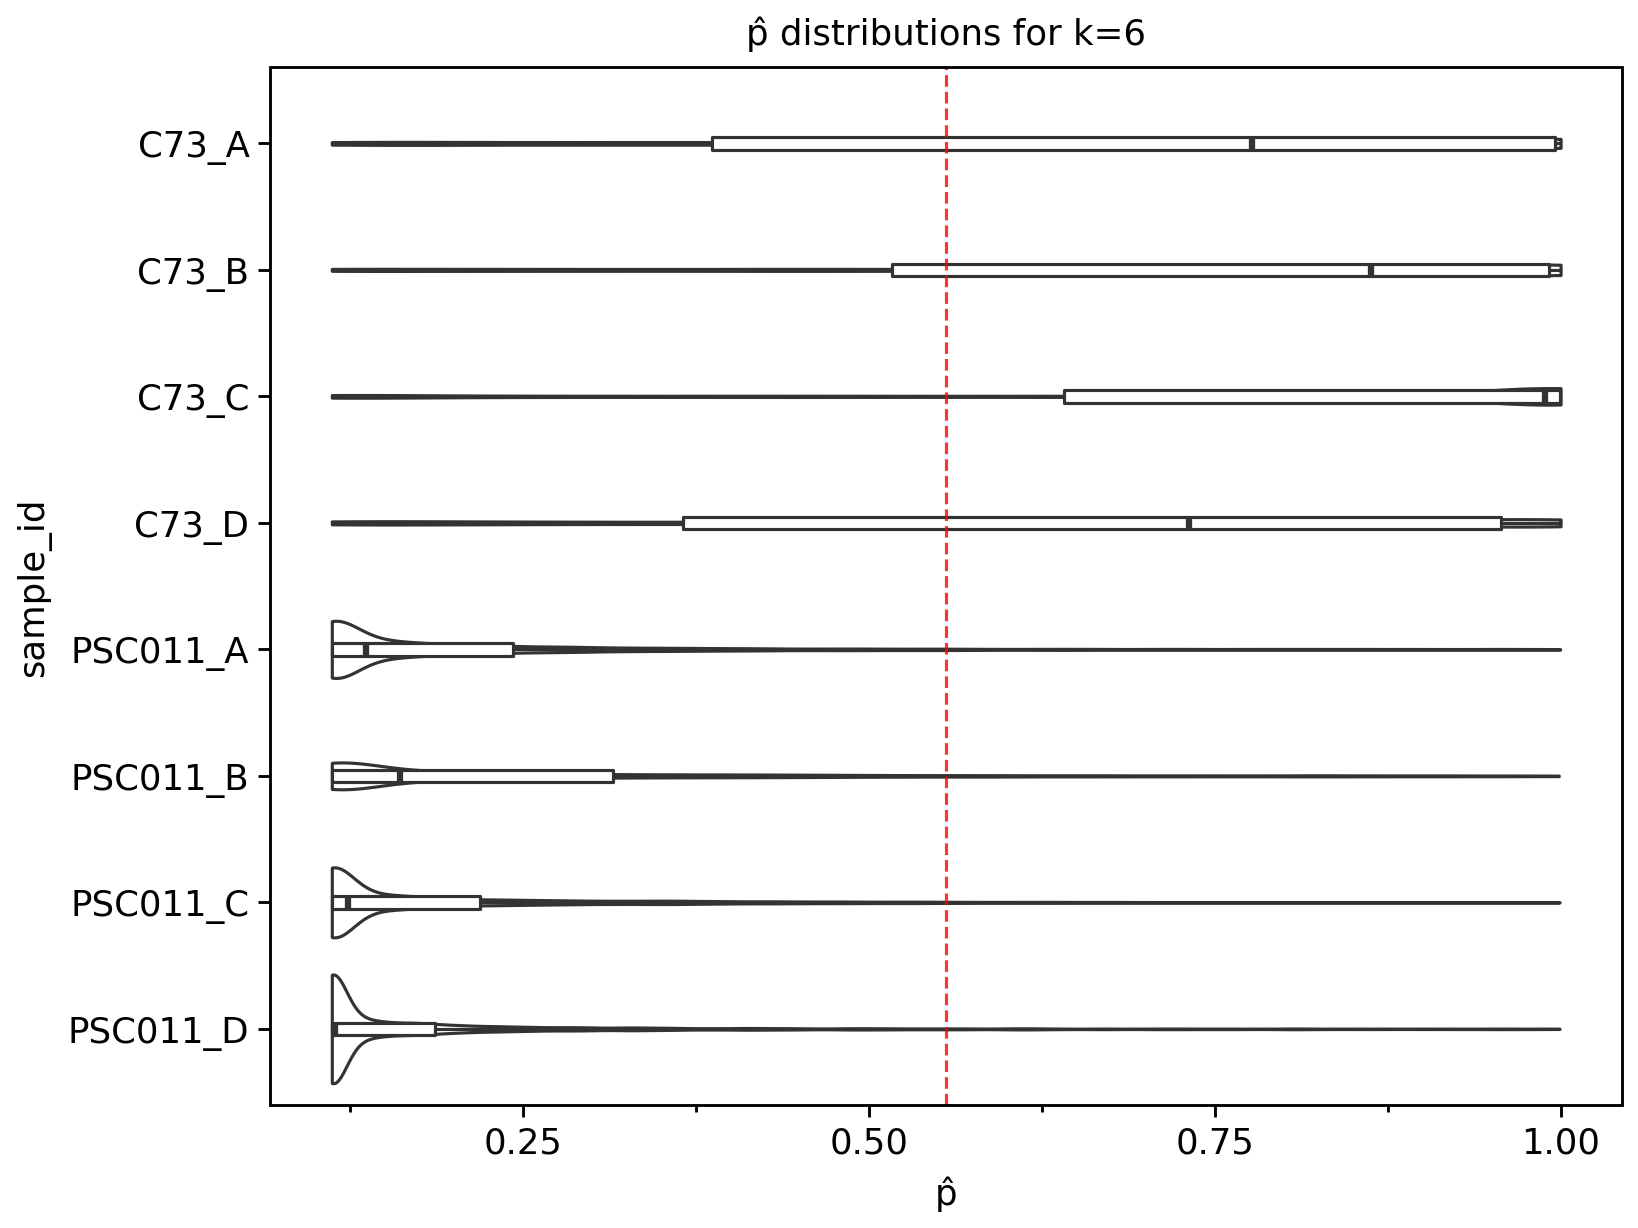

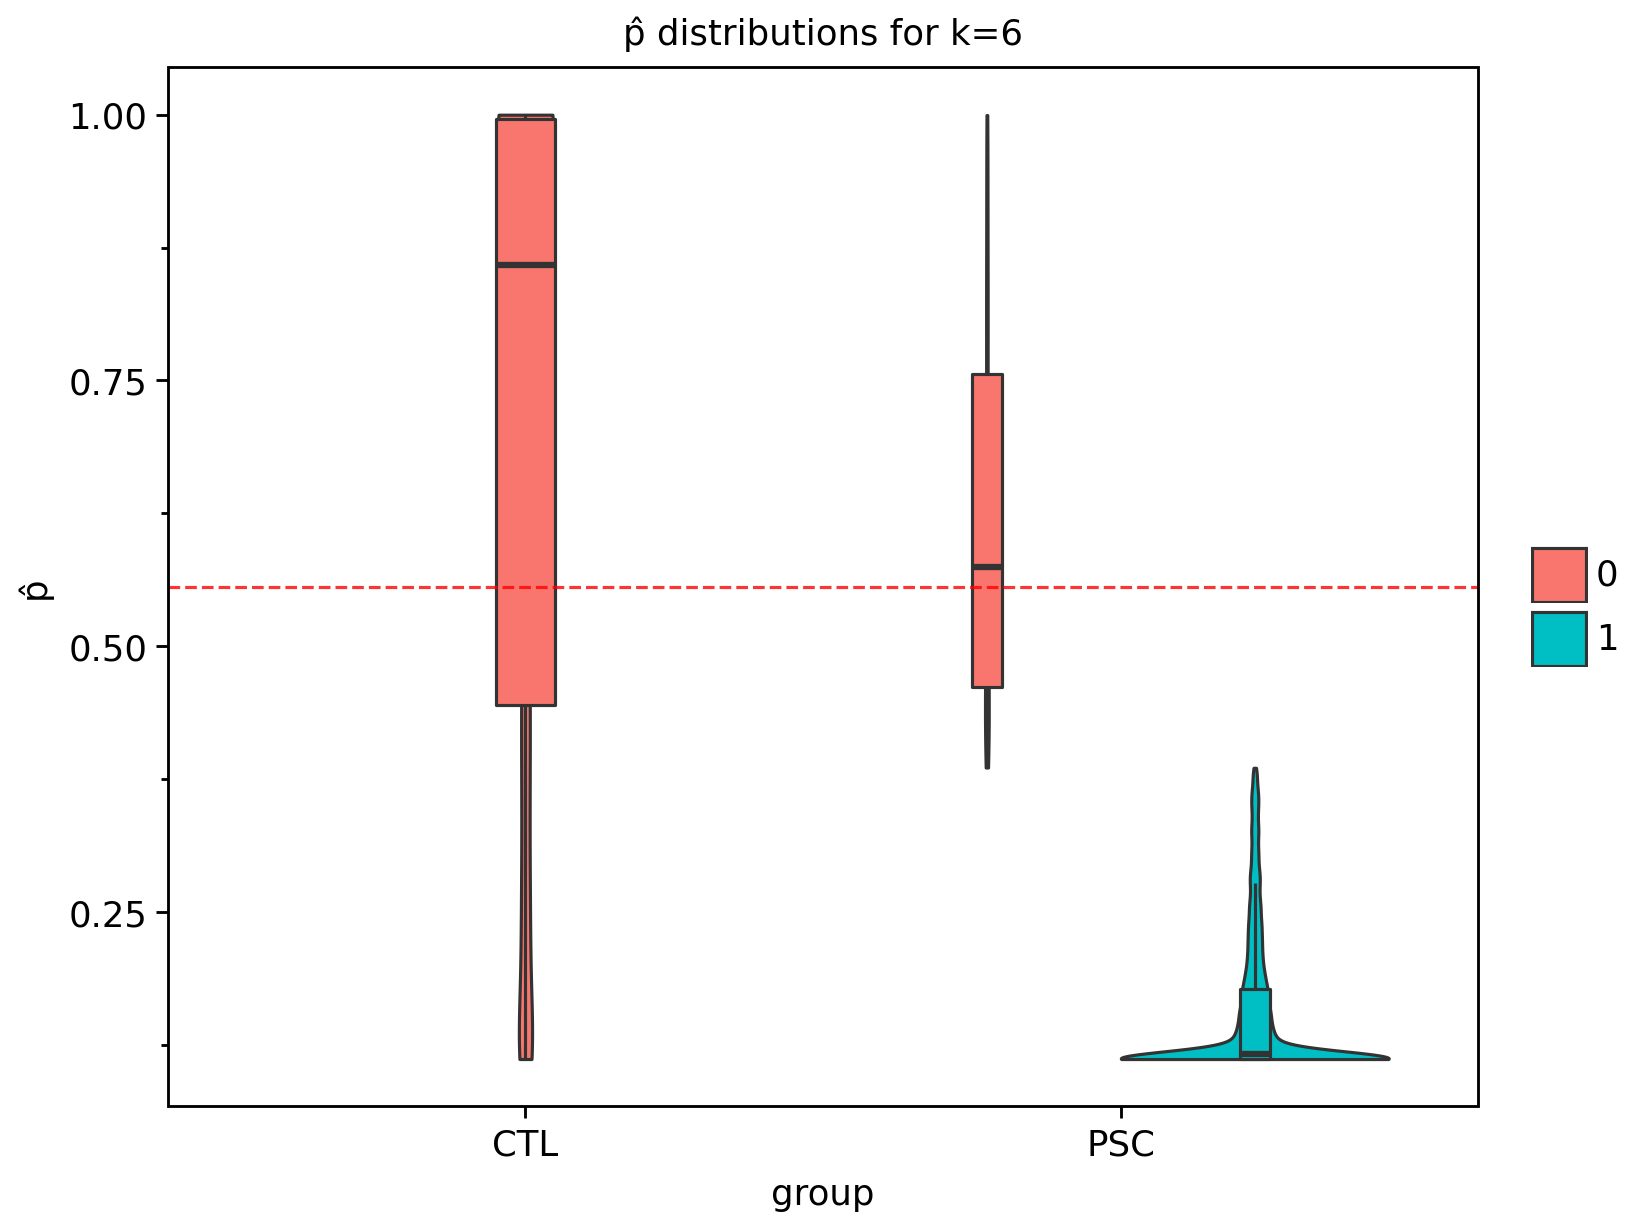

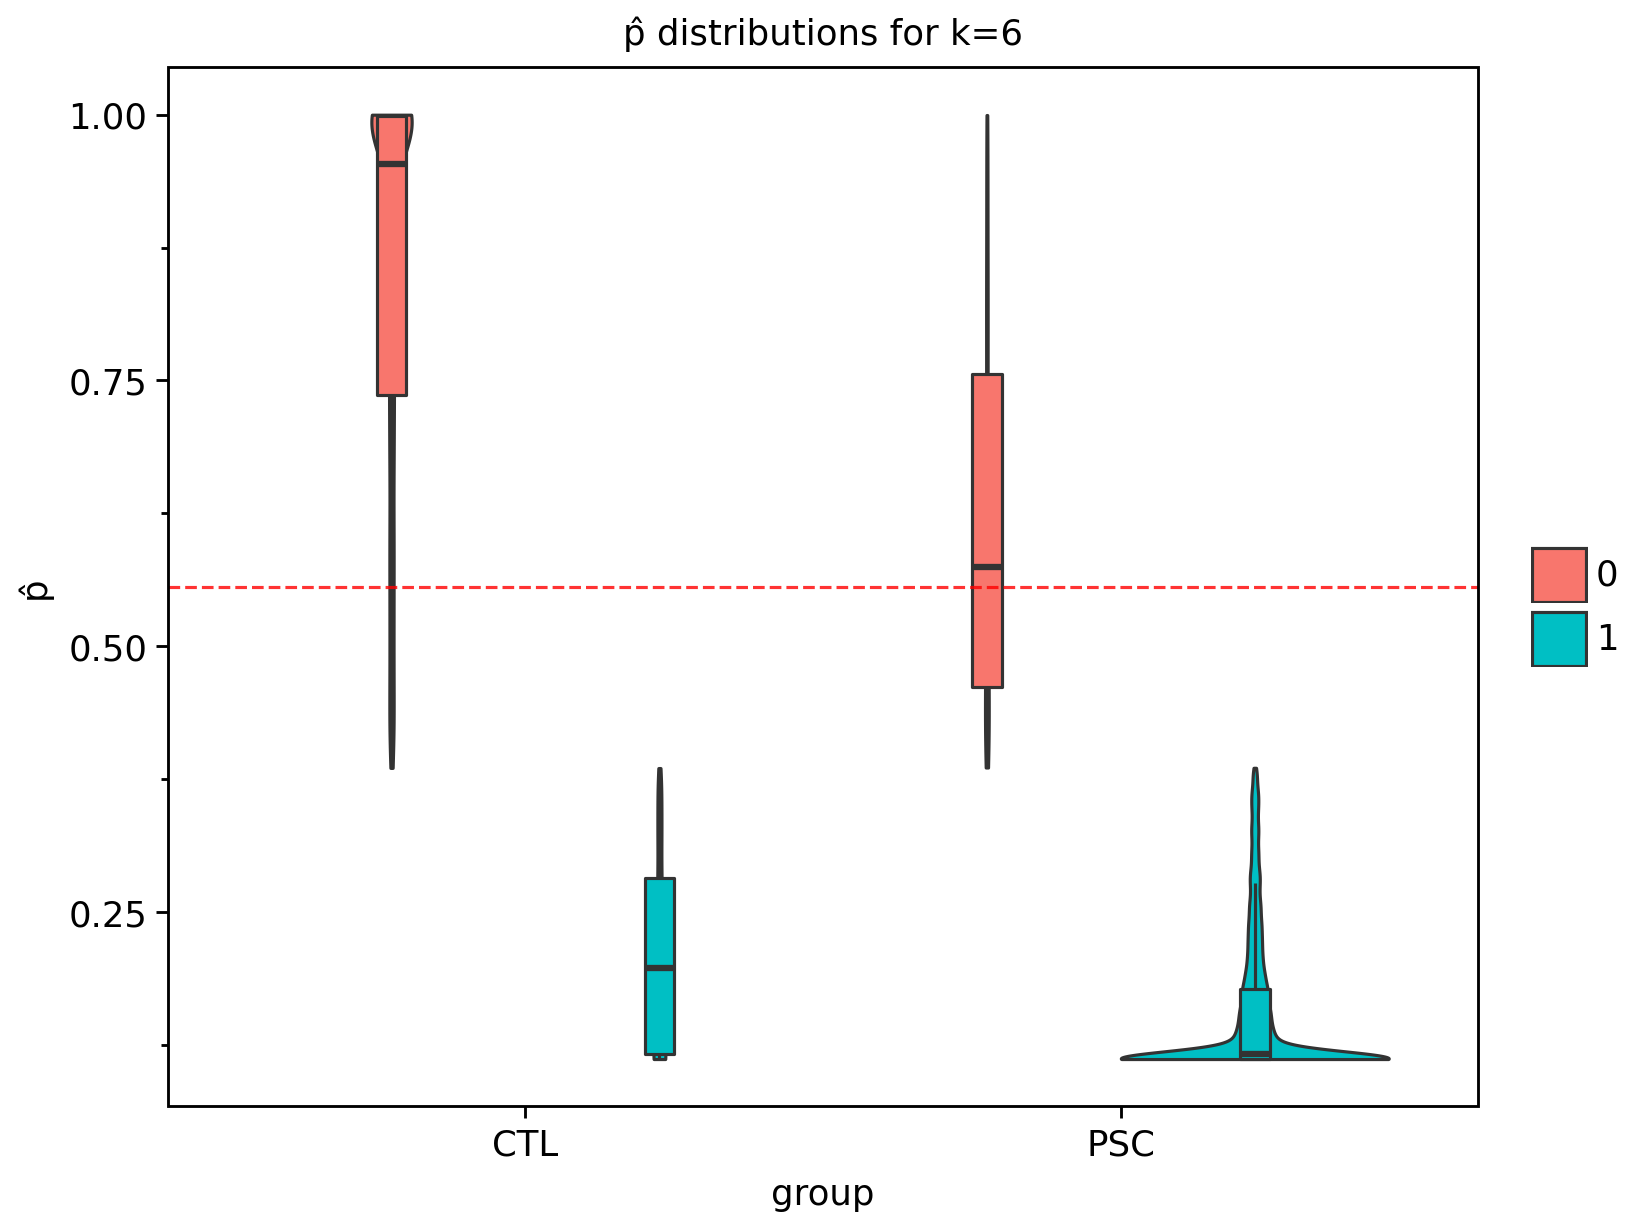

In [10]:
for p in pl_help(psc, 6).values():
    p.show()

to explore this further, we proceed w/ a gene-wise analysis for factor 4, which has the largest beta:

In [11]:
ks_oi = [4]
for k in ks_oi:
    sP.run_gene_reg(psc, SP_FACT_PAT_STR.format(k=k), SP_GENE_PAT_STR.format(k=k), layer="counts", run_reg=False)

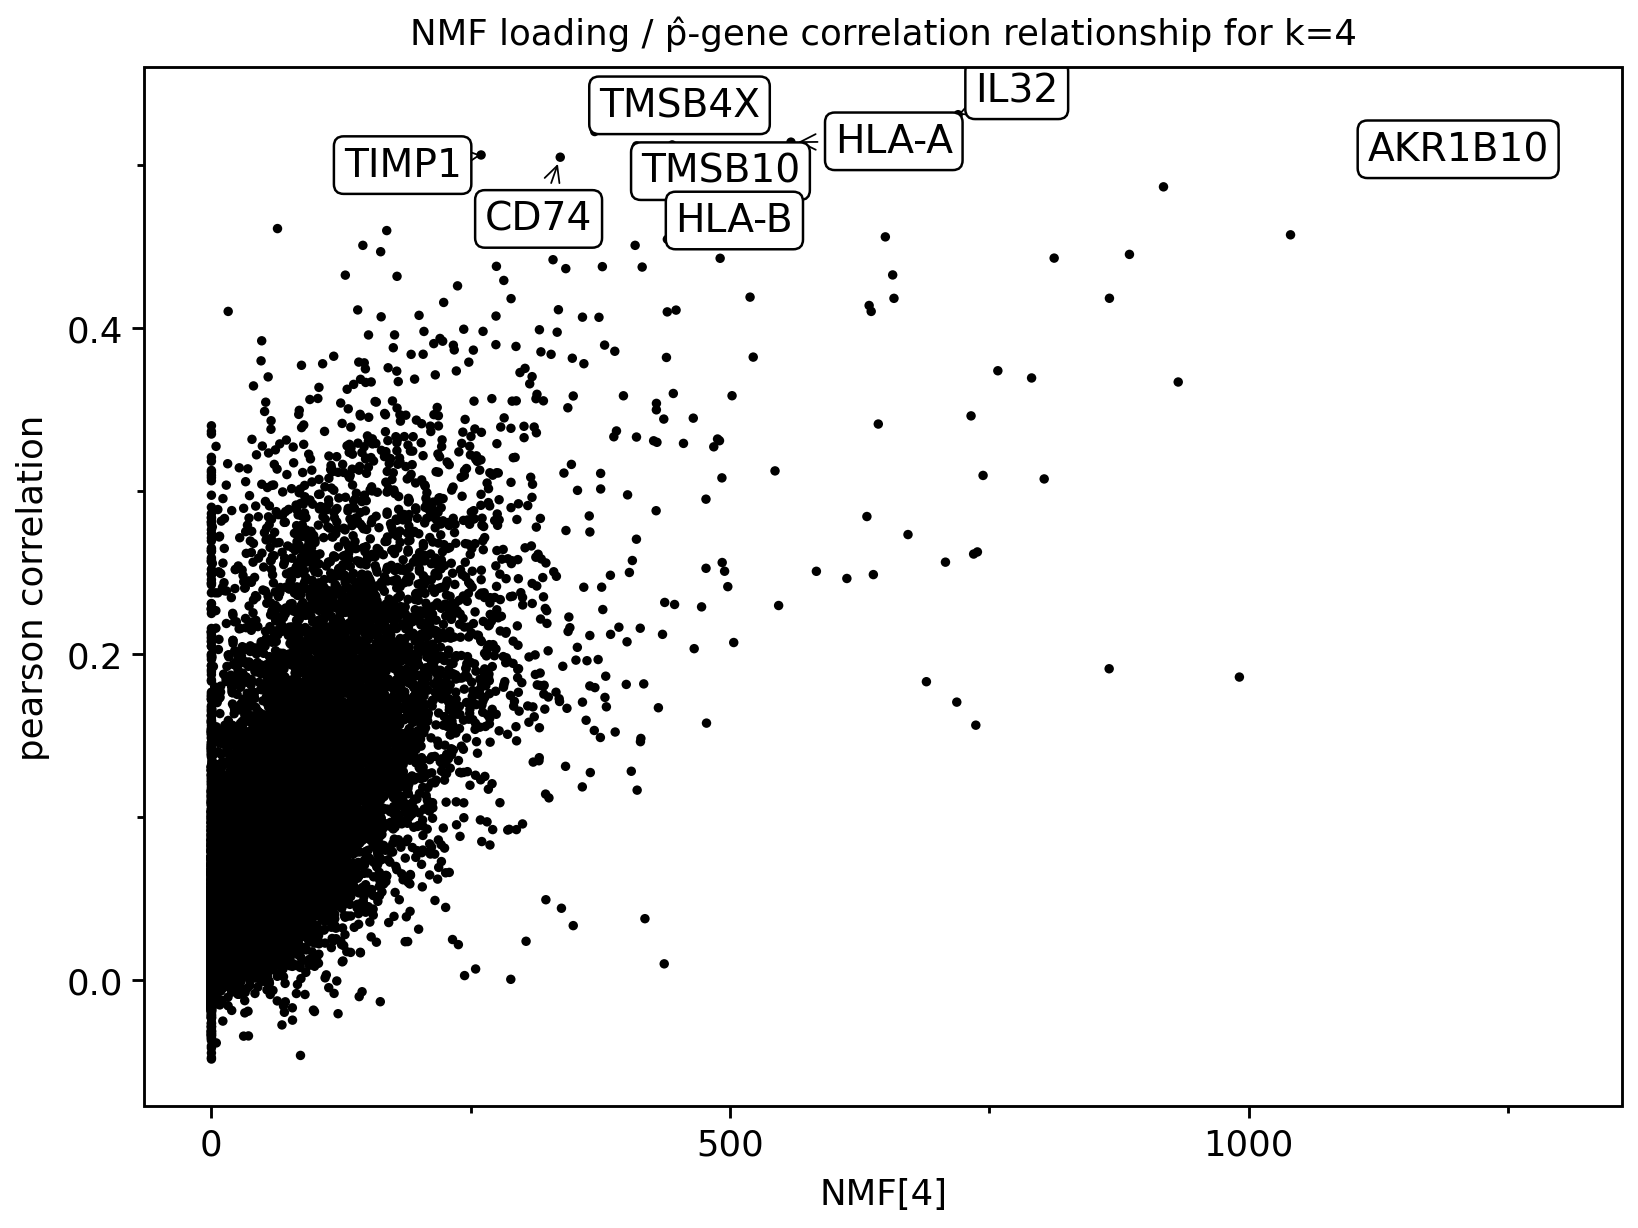

In [12]:
for k in ks_oi:
    (
        uapl.PlotAdata(psc)
        + aes(
            x=uapl.varm("X_nmf", k),
            y=uapl.varm(SP_GENE_PAT_STR.format(k=k), "corr"),
            label=np.where(
                np.argsort(np.argsort(-np.abs(np.asarray(psc.varm[SP_GENE_PAT_STR.format(k=k)]["corr"])))) < 8,
                psc.var["SYMBOL"],
                None,  # ty:ignore[invalid-argument-type]
            ),
        )
        + geom_point(size=1.5, shape="o", stroke=0)
        + geom_label(adjust_text={}, na_rm=True)
        + labs(
            colour="-log(pval)",
            x=f"NMF[{k}]",
            y="pearson correlation",
            title=f"NMF loading / p\u0302-gene correlation relationship for k={k}",
        )
    ).show()

In [13]:
degs = {k: run_deg_groups(psc, k, "group", "CTL") for k in ks_oi}
sig_sub = {k: degs[k].loc[lambda e: (e["adj_pval"] < 0.05) & (e["lfc"].abs() > 1)] for k in ks_oi}

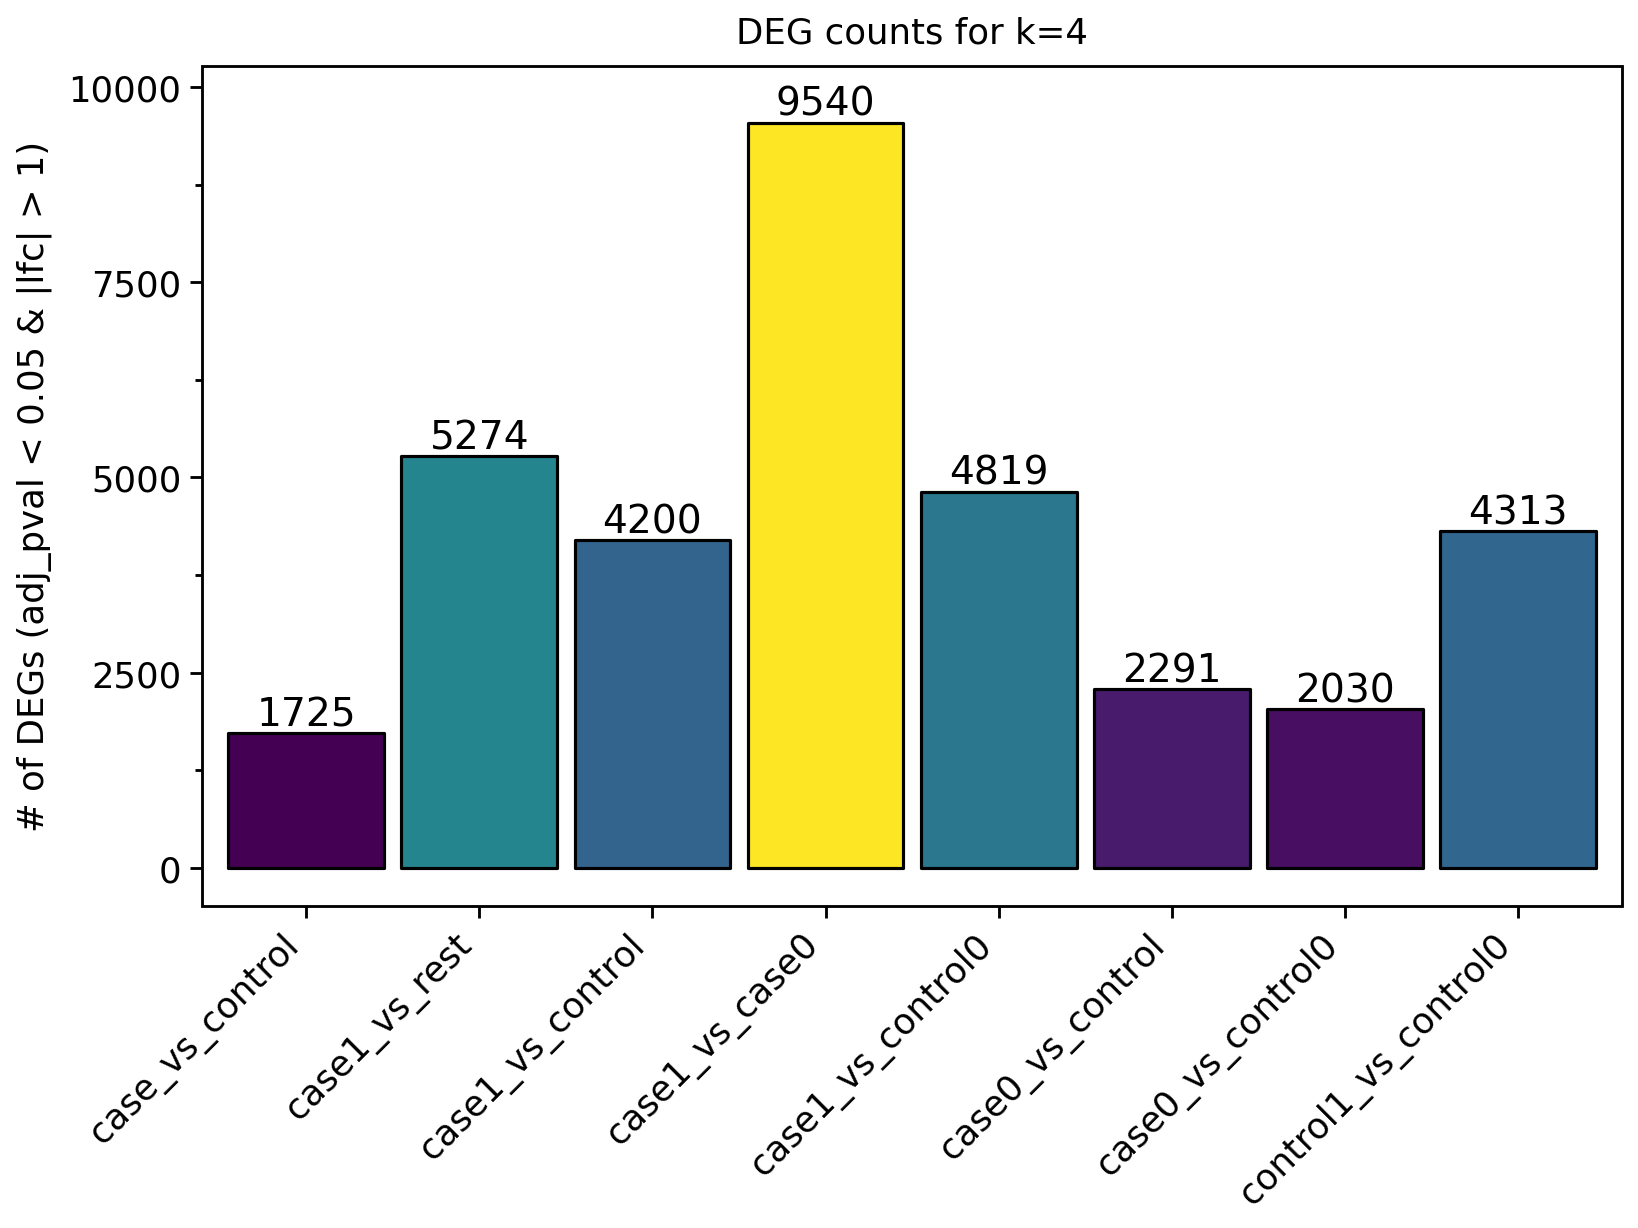

In [14]:
for k in ks_oi:
    sig_counts = sig_sub[k].groupby("cmp", observed=True)["gene"].count()
    (
        ggplot(sig_counts.reset_index(drop=False))
        + aes(x="cmp", y="gene", fill=after_stat("y"), label=after_stat("y"))
        + geom_col(color="black")
        + geom_text(nudge_y=sig_counts.max() * 0.025)
        + theme(axis_text_x=element_text(angle=45, hjust=1))
        + guides(fill="none")
        + labs(x="", y="# of DEGs (adj_pval < 0.05 & |lfc| > 1)", title=f"DEG counts for k={k}")
    ).show()

we can further visualize the permutations of gene set size in these comparisons via the upsetplot package:

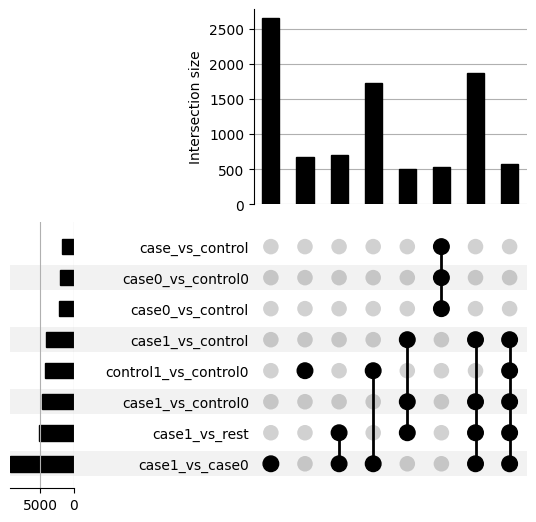

In [15]:
for k in ks_oi:
    with catch_warnings():
        simplefilter(action="ignore", category=FutureWarning)
        up.UpSet(
            up.from_contents({k: v.array for k, v in sig_sub[k].groupby("cmp", observed=True)["gene"]}),
            subset_size="count",
            max_subset_rank=8,
        ).plot()

    plt.show()